# Multiple Instance Learning (MIL) for patient-level prediction

In this tutorial we show how to use **Multiple Instance Learning (MIL)** to predict patient-level phenotypes from single-cell data with `patpy`.

## The MIL idea

Each patient is represented as a *bag* of cells.  A MIL model learns a **weighted aggregation** over those cells — giving higher weight to the cells most predictive of the label — and maps the resulting bag embedding to a patient-level prediction.

```
patient ──► [cell₁, cell₂, …, cellₙ] ──► attention weights ──► bag embedding ──► label
```

## What this tutorial covers

1. **Data loading & QC** — reading a large single-cell dataset, computing cell counts and composition, filtering low-coverage patients
2. **Stratified patient splits** — creating reproducible train / val / test folds at the patient level
3. **MIL benchmark** — cross-validated comparison of `MixMIL` and `ABMIL` across multiple labels
4. **Full-dataset retraining** — training final models on all data and inspecting training loss
5. **Patient representation UMAPs** — visualising the bag embeddings learned by MixMIL
6. **Attention visualisations** — projecting per-cell attention weights onto the single-cell UMAP, bar plots by cell type, and patient × cell-type heatmaps
7. **Representation benchmark** — fitting a simple linear probe on top of unsupervised (pseudobulk, composition) and supervised (MixMIL, ABMIL) representations and comparing predictive performance


## Setup

Standard imports.  `patpy.pp` handles preprocessing (QC, splits) and `patpy.tl` provides the MIL models and benchmarking utilities.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import patpy
import patpy.pp
import patpy.tl
import patpy.pl
from patpy.tl.supervised import MixMIL
from patpy.tl.mil_models import ABMIL
from patpy.tl.benchmark import MILBenchmark

sc.settings.verbosity = 1

In [2]:
patpy.__version__

'0.15.2'

## Data

We use the [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed) — a blood atlas of COVID-19 with **~780k PBMCs** from 140 donors spanning healthy volunteers, mild, severe, and critical COVID-19, as well as sepsis and flu controls.

> **Why COMBAT for MIL?**  Every cell carries a donor ID and a patient-level label (disease severity, outcome score, …).  This maps perfectly onto the bag-of-cells formulation: each patient is a bag and the task is to predict their clinical label from their cellular composition and gene expression.

The `LABELS` dict defines which columns to predict and the task type.  You can add or remove entries without changing any other code.


In [3]:
ADATA_PATH = "path/to/combat_processed.h5ad"  # download from https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed

# Labels to train a separate MIL model for each entry
# Format: {column_name: task}  task = "classification" | "regression"
LABELS = {
    "binary_condition": "classification",
    "Source":           "classification",
    "Outcome":          "classification",
}


In [5]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783704 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

## Key column names

| Variable | Description |
|---|---|
| `sample_key` | Column in `adata.obs` that identifies each donor/patient |
| `cell_type_key` | Column with cell-type annotations (used for attention plots) |
| `metadata_cols` | Patient-level columns to carry along for plotting |

We rename `Annotation_major_subset` → `cell_type` and create a binary `binary_condition` column (1 = any COVID-19, 0 = healthy).  Donors with missing labels for any target are dropped.


In [6]:
sample_key    = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
metadata_cols = ["Source", "Outcome", "Death28", "Institute"] + list(LABELS.keys())
metadata_cols = list(dict.fromkeys(metadata_cols))  # deduplicate


In [7]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

# Keep only COVID-19 and healthy donors
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]

# Binary label: 1 = COVID-19, 0 = healthy
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)

# Drop rows where any label is missing
for lk in LABELS:
    if lk in adata.obs.columns:
        adata = adata[adata.obs[lk].notna()].copy()

adata.obs["binary_condition"].value_counts()


binary_condition
1    524557
0     87204
Name: count, dtype: int64

## QC and filtering

Before training, we apply two quality-control steps:

1. **Cell counts per patient** — patients with very few cells produce unreliable bag statistics.  We remove patients below a minimum cell threshold (250 cells).
2. **Composition overview** — a stacked bar chart of cell-type proportions per patient gives a quick sanity check on the data and helps spot outlier samples.


In [8]:
metadata = (
    adata.obs[[sample_key] + metadata_cols]
    .drop_duplicates()
    .set_index(sample_key)
)
n_cells     = patpy.pp.calculate_n_cells_per_sample(adata, sample_key)
composition = patpy.pp.calculate_compositional_metrics(adata, sample_key, [cell_type_key], normalize_to=100)
metadata = pd.concat([metadata, n_cells.loc[metadata.index], composition.loc[metadata.index]], axis=1)
metadata.head()


,Source,Outcome,Death28,Institute,binary_condition,n_cells,cell_type_B,cell_type_CD4,cell_type_CD8,cell_type_DC,...,cell_type_HSC,cell_type_MAIT,cell_type_Mast,cell_type_NK,cell_type_PB,cell_type_PLT,cell_type_RET,cell_type_cMono,cell_type_iNKT,cell_type_ncMono
scRNASeq_sample_ID,,,,,,,,,,,,,,,,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,1,3984,12.048193,19.954819,10.065261,0.401606,...,0.200803,1.004016,0.000000,20.682731,2.459839,0.075301,0.0251,28.664659,0.050201,1.079317
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,1,7384,17.768147,36.633261,5.958830,1.096966,...,0.135428,0.352113,0.000000,7.624594,2.816901,0.067714,0.0000,23.171723,0.013543,2.559588
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,1,9002,3.310375,73.583648,9.853366,0.188847,...,0.099978,0.288825,0.000000,4.598978,1.832926,0.444346,0.0000,2.777161,0.000000,0.444346
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,1,4278,5.352969,28.821879,5.937354,1.496026,...,0.210379,0.327256,0.000000,8.952782,1.005143,0.116877,0.0000,43.010753,0.023375,3.295933
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,1,7600,4.052632,38.065789,4.131579,2.171053,...,0.973684,0.039474,0.026316,5.263158,1.131579,0.236842,0.0000,39.960526,0.013158,2.486842


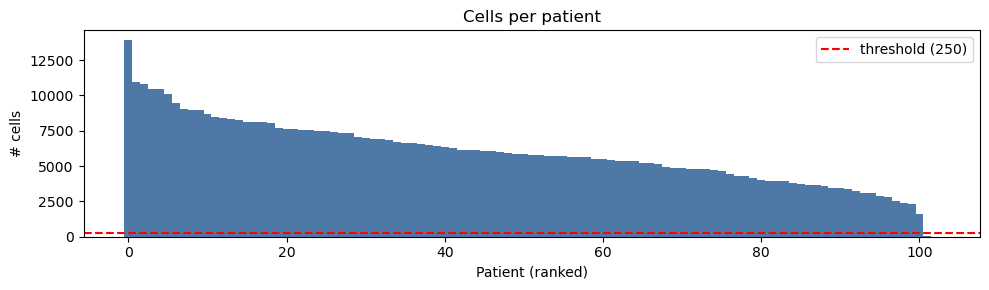

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(n_cells)), n_cells["n_cells"].sort_values(ascending=False).values,
       color="#4e79a7", width=1)
ax.axhline(250, color="red", linestyle="--", label="threshold (250)")
ax.set_xlabel("Patient (ranked)")
ax.set_ylabel("# cells")
ax.set_title("Cells per patient")
ax.legend()
plt.tight_layout()


In [10]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_key, sample_size_threshold=250)
print(f"After QC: {adata.n_obs:,} cells | {adata.obs[sample_key].nunique()} patients")


2 samples removed: G05092-Ja005E-PBCa, S00030-Ja003E-PBCa


After QC: 611,734 cells | 101 patients


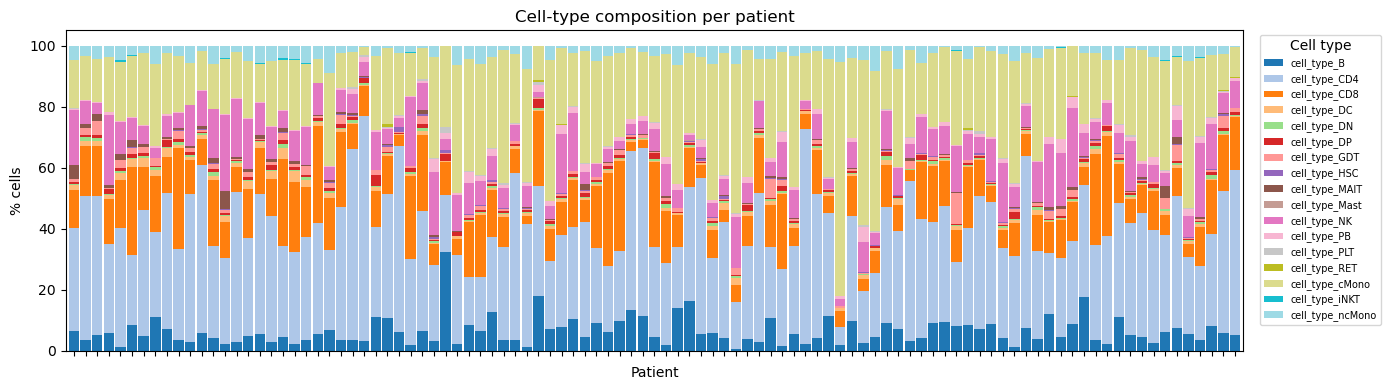

In [11]:
comp_plot = composition.loc[composition.index.isin(adata.obs[sample_key].unique())]
fig, ax = plt.subplots(figsize=(14, 4))
comp_plot.plot.bar(stacked=True, ax=ax, colormap="tab20", legend=True, width=0.9)
ax.set_xticklabels([])
ax.set_xlabel("Patient")
ax.set_ylabel("% cells")
ax.set_title("Cell-type composition per patient")
ax.legend(title="Cell type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()


## Stratified patient-level splits

Data leakage is the most common pitfall in MIL benchmarking: if cells from the same patient appear in both train and test, performance is artificially inflated.

`patpy.pp.make_sample_splits` creates **patient-level** stratified folds:
- Stratification is by the first label so class proportions are balanced across folds
- Three split columns (`split_0`, `split_1`, `split_2`) are written to `adata.obs` —   one per cross-validation fold
- The **same splits are reused for every label**, making results directly comparable


In [12]:
first_label = list(LABELS.keys())[0]

patpy.pp.make_sample_splits(
    adata,
    sample_key=sample_key,
    label_key=first_label,
    test_size=0.2,
    val_size=0.15,
    n_splits=3,
    seed=42,
)

split_cols = sorted([c for c in adata.obs.columns if c.startswith("split")])
print("Split columns written:", split_cols)


Split columns written: ['split_0', 'split_1', 'split_2']


In [13]:
# Compute cell UMAP once for attention visualisations
if "X_umap" not in adata.obsm:
    sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15)
    sc.tl.umap(adata)
print("UMAP ready")


UMAP ready


## Helper utilities

`_get_importance` is a thin wrapper that calls `get_cell_importance` with the right arguments regardless of whether the model supports the `normalized` parameter (MixMIL and ABMIL have slightly different APIs).

`make_models` constructs a fresh pair of models for each label / cross-validation fold to avoid any state leaking between runs.


In [14]:
import inspect as _inspect

def _get_importance(model, label):
    sig = _inspect.signature(model.get_cell_importance)
    if "normalized" in sig.parameters:
        return model.get_cell_importance(label=label, normalized=False)
    return model.get_cell_importance(label=label)


def make_models(label_key, task):
    models = {
        "MixMIL": MixMIL(
            sample_key=sample_key, label_keys=[label_key],
            tasks=[task], layer="X_pca", n_epochs=200,
        ),
        "ABMIL": ABMIL(
            sample_key=sample_key, label_keys=[label_key],
            tasks=[task], layer="X_pca", att_dim=128, n_epochs=200,
        ),
    }
    return models


## Per-label MIL training and evaluation

For each label in `LABELS` the following steps run automatically:

| Step | What happens |
|---|---|
| **Label distribution** | Bar + pie chart of patient counts per class |
| **Split overview** | Sanity-check that each split is class-balanced |
| **`MILBenchmark`** | 3-fold cross-validation of MixMIL and ABMIL; outputs AUROC, balanced accuracy, F1, AUPR |
| **Full-dataset retrain** | Trains both models on all patients to produce final attention maps |
| **Training loss** | Convergence curves for both models |
| **Patient UMAP** | UMAP of the MixMIL bag embeddings coloured by label |
| **Representation quality** | KNN score measuring how well the embedding separates patients by label |
| **ROC curve** | Per-model ROC for binary labels |
| **Attention UMAP** | Per-cell attention weights projected onto the single-cell UMAP |
| **Attention by cell type** | Mean attention per cell-type cluster |
| **Attention heatmap** | Patient × cell-type attention matrix |

### Models

**MixMIL** ([Engelmann et al. 2024](https://arxiv.org/abs/2311.02455))  
A probabilistic MIL model based on a Gaussian linear mixed model.  Attention weights are learned via a softmax over learned scores.

**ABMIL** ([Ilse et al. 2018](https://arxiv.org/abs/1802.04712))  
Gated attention-based MIL.  A two-layer attention network produces per-cell weights; the weighted sum of cell embeddings is the bag representation.



  Label: binary_condition  |  Task: classification


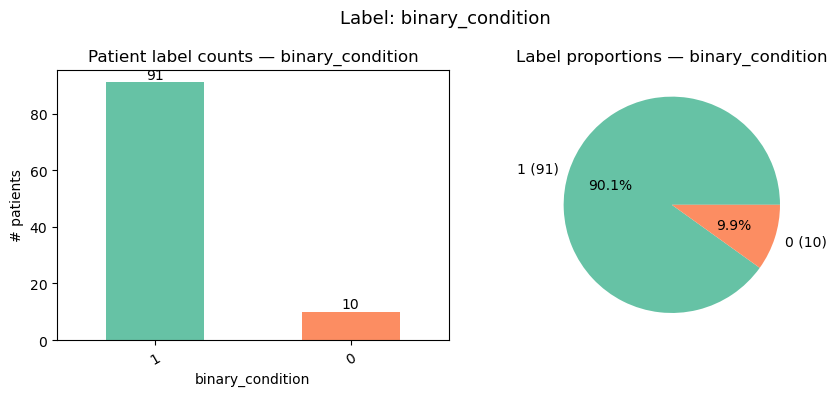

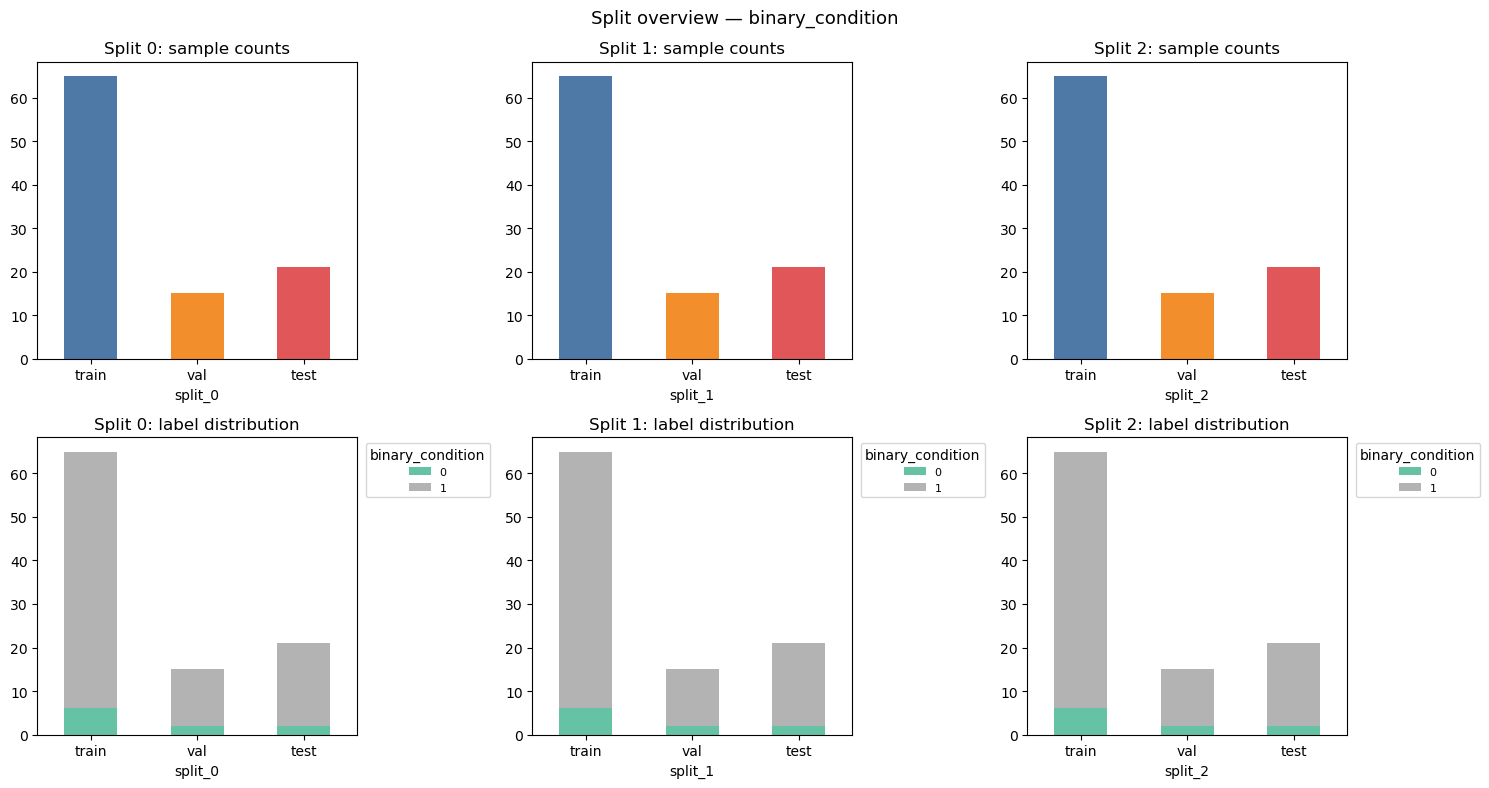

GLMM Init:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                                        mean     std
model  eval_split label            metric                           
ABMIL  test       binary_condition aupr               1.0000  0.0000
                                   auroc              1.0000  0.0000
                                   balanced_accuracy  0.9167  0.1443
                                   f1_weighted        0.9817  0.0317
       val        binary_condition aupr               1.0000  0.0000
                                   auroc              1.0000  0.0000
                                   balanced_accuracy  1.0000  0.0000
                                   f1_weighted        1.0000  0.0000
MixMIL test       binary_condition aupr               0.9975  0.0025
                                   auroc              0.9737  0.0263
                                   balanced_accuracy  0.7456  0.0662
                                   f1_weighted        0.6183  0.1124
       val       

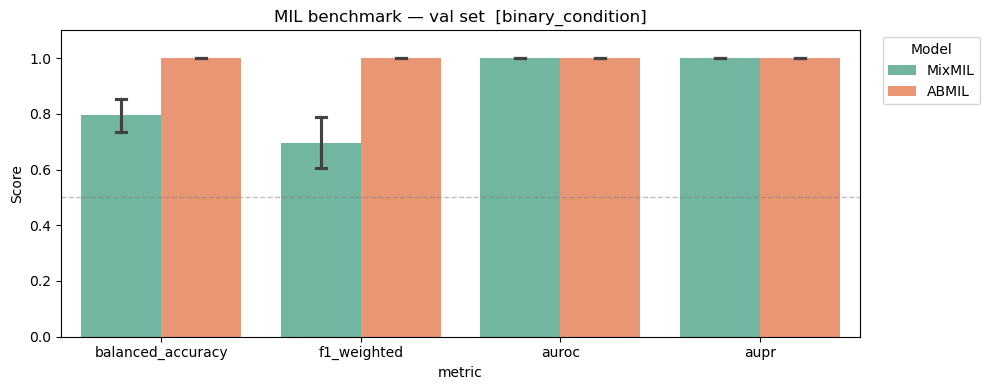

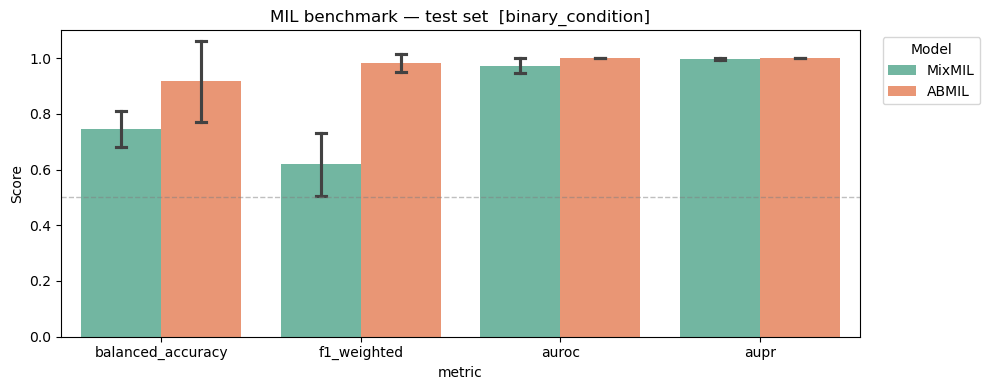

GLMM Init:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

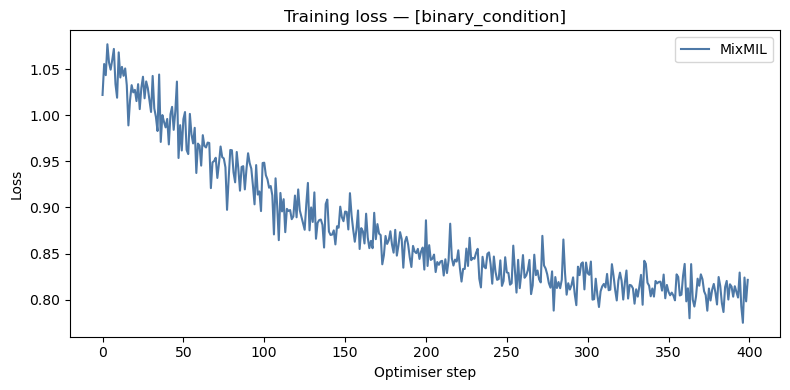

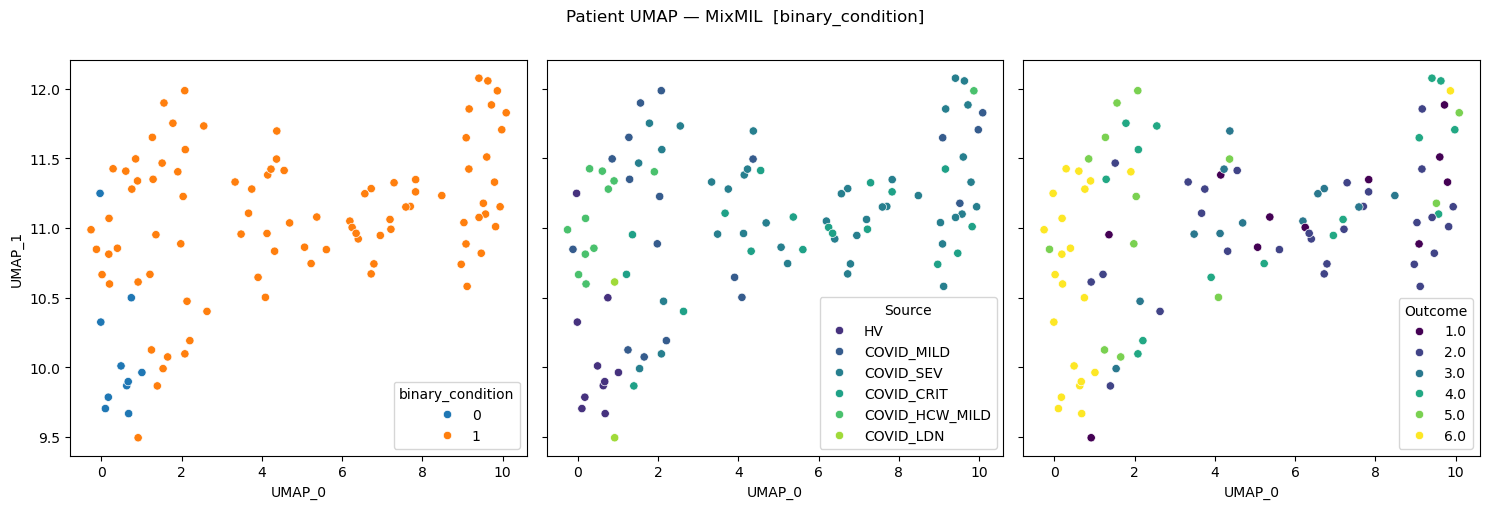

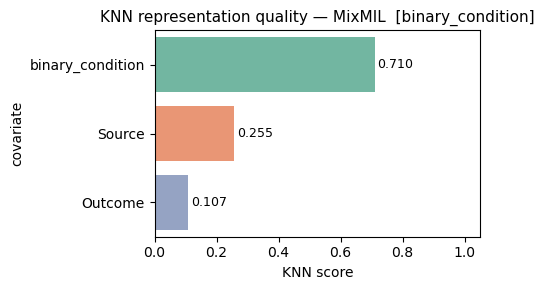

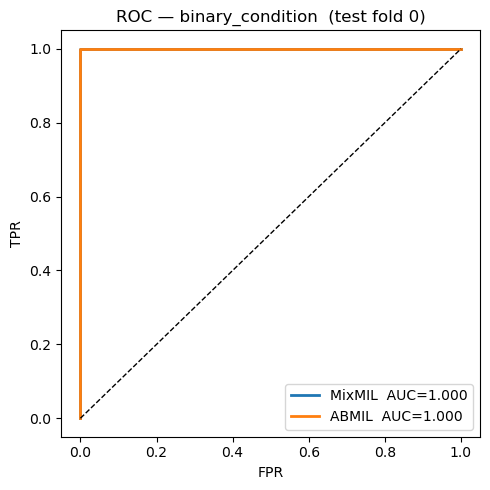

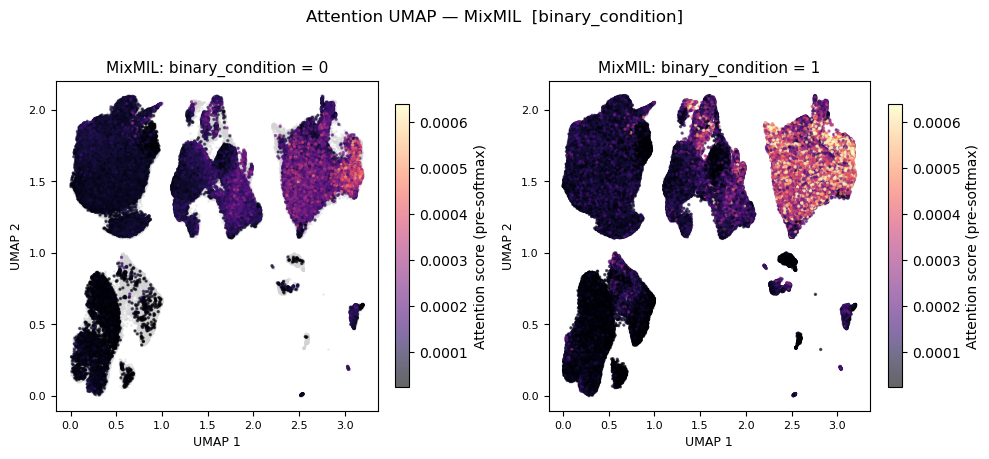

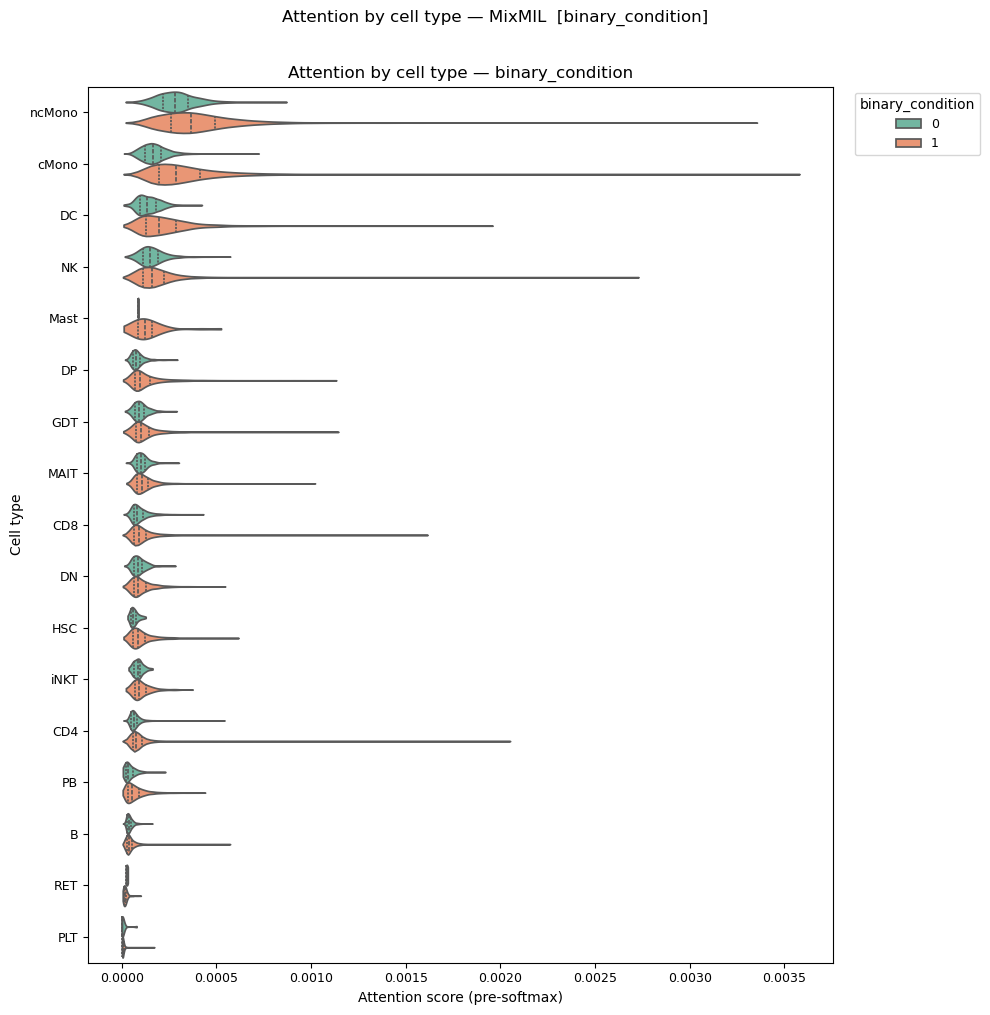

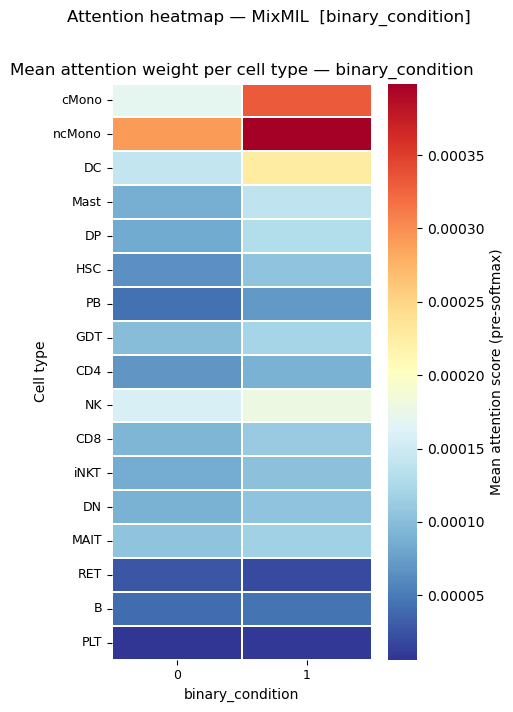

  → adata.obs['MixMIL_binary_condition_attention'] written


No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


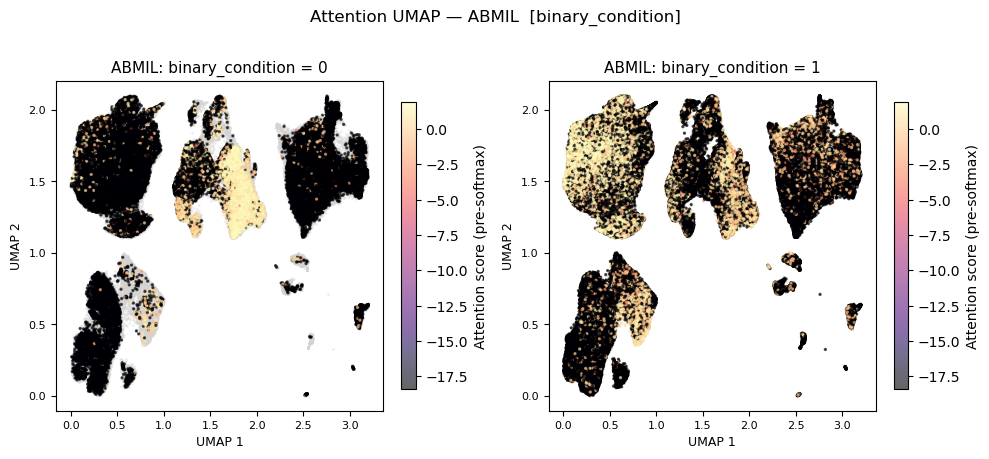

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


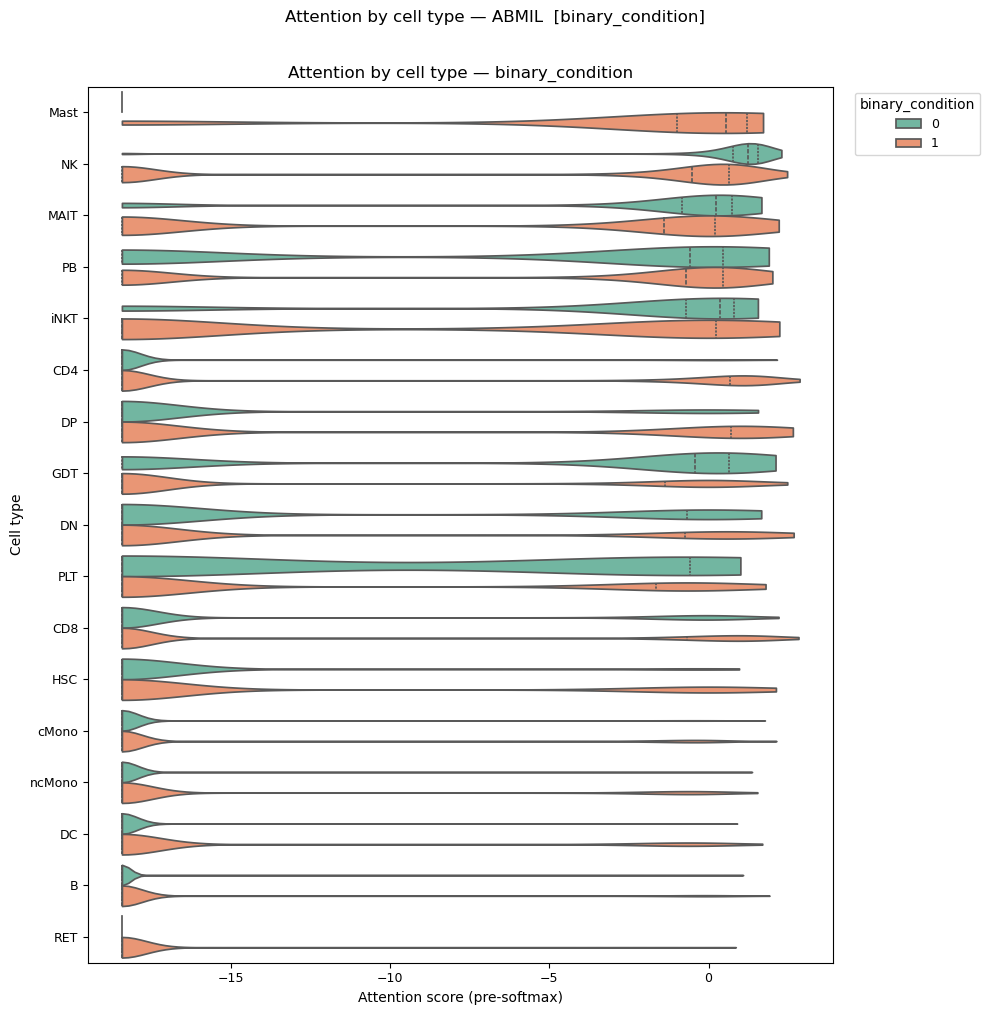

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


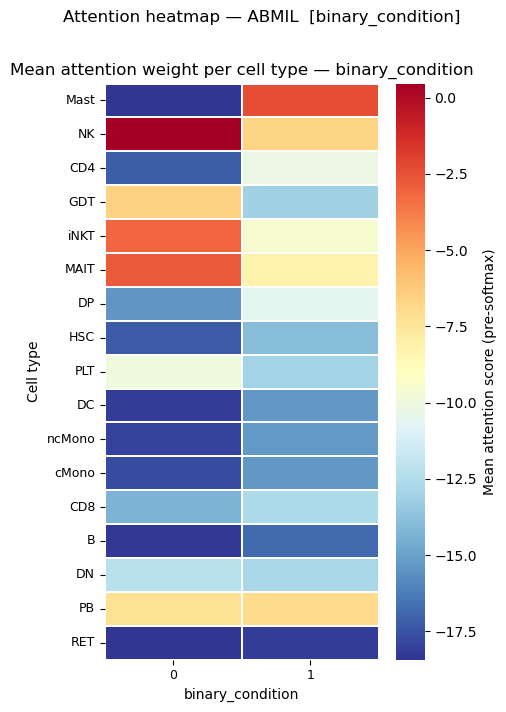

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


  → adata.obs['ABMIL_binary_condition_attention'] written

  Label: Source  |  Task: classification


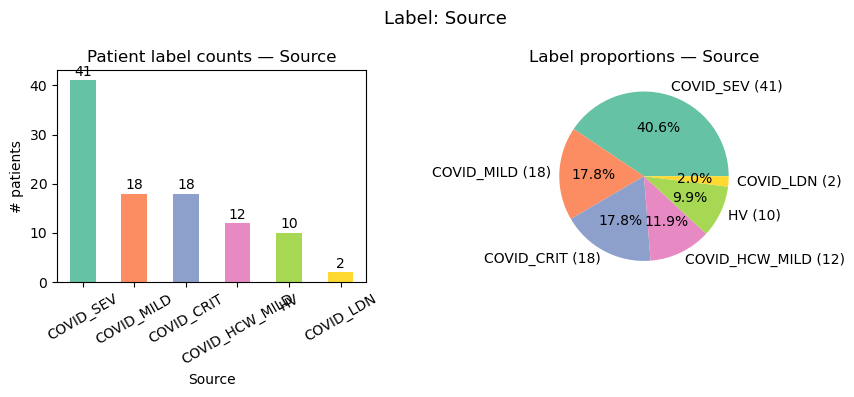

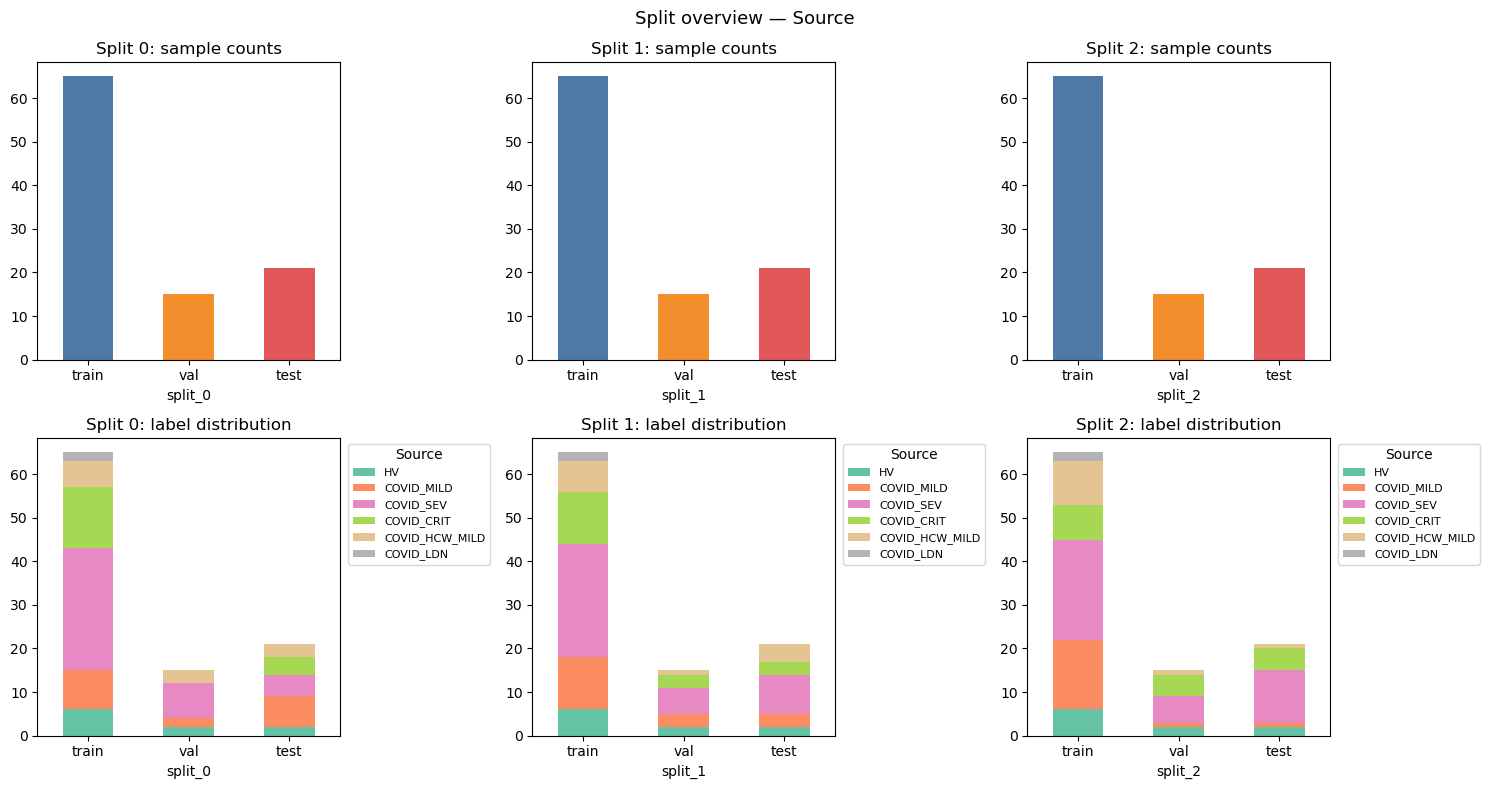

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                              mean     std
model  eval_split label  metric                           
ABMIL  test       Source balanced_accuracy  0.5703  0.1772
                         f1_weighted        0.4820  0.1138
       val        Source balanced_accuracy  0.7574  0.1472
                         f1_weighted        0.7280  0.1822
MixMIL test       Source balanced_accuracy  0.4419  0.0812
                         f1_weighted        0.3744  0.0901
       val        Source balanced_accuracy  0.5403  0.1439
                         f1_weighted        0.4495  0.2348


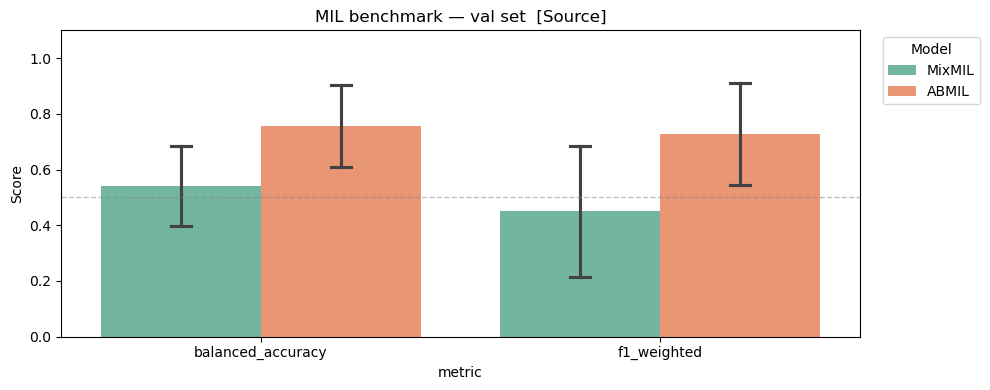

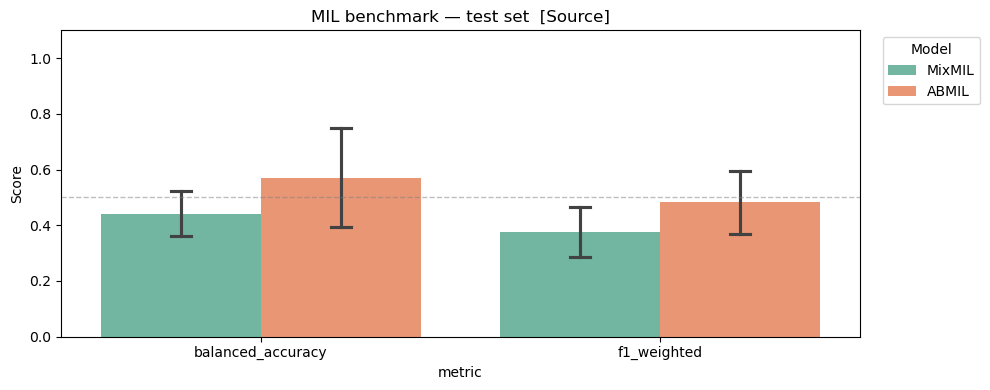

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

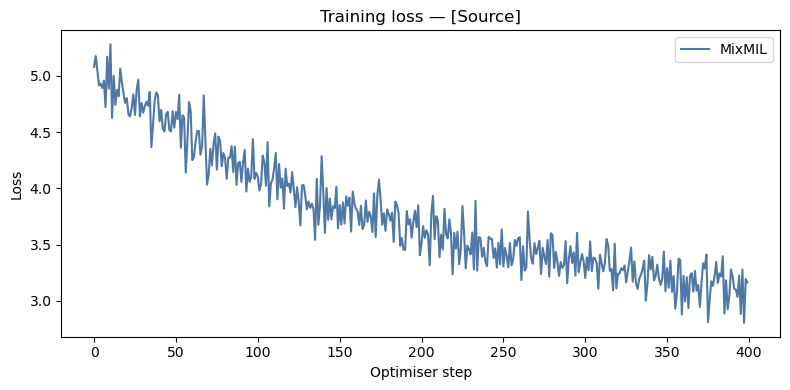

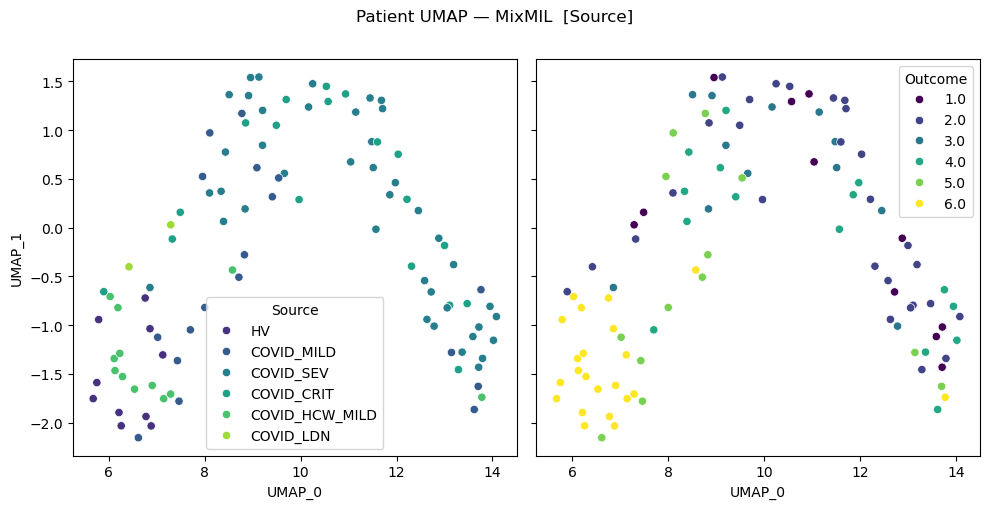

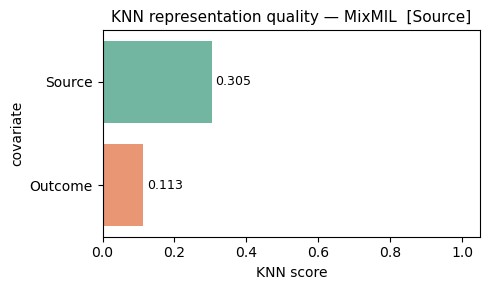

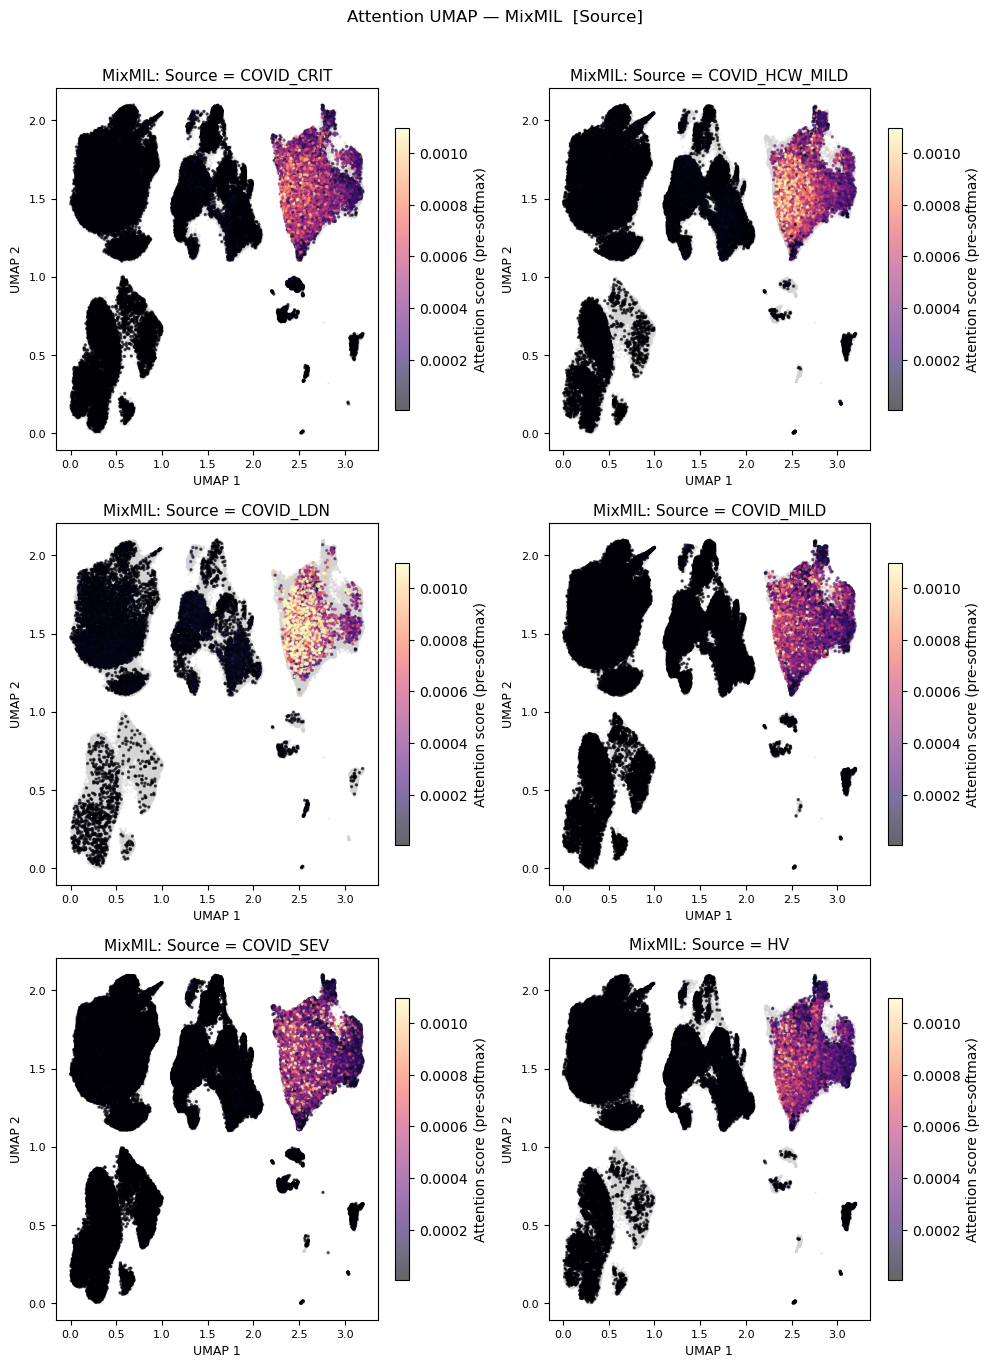

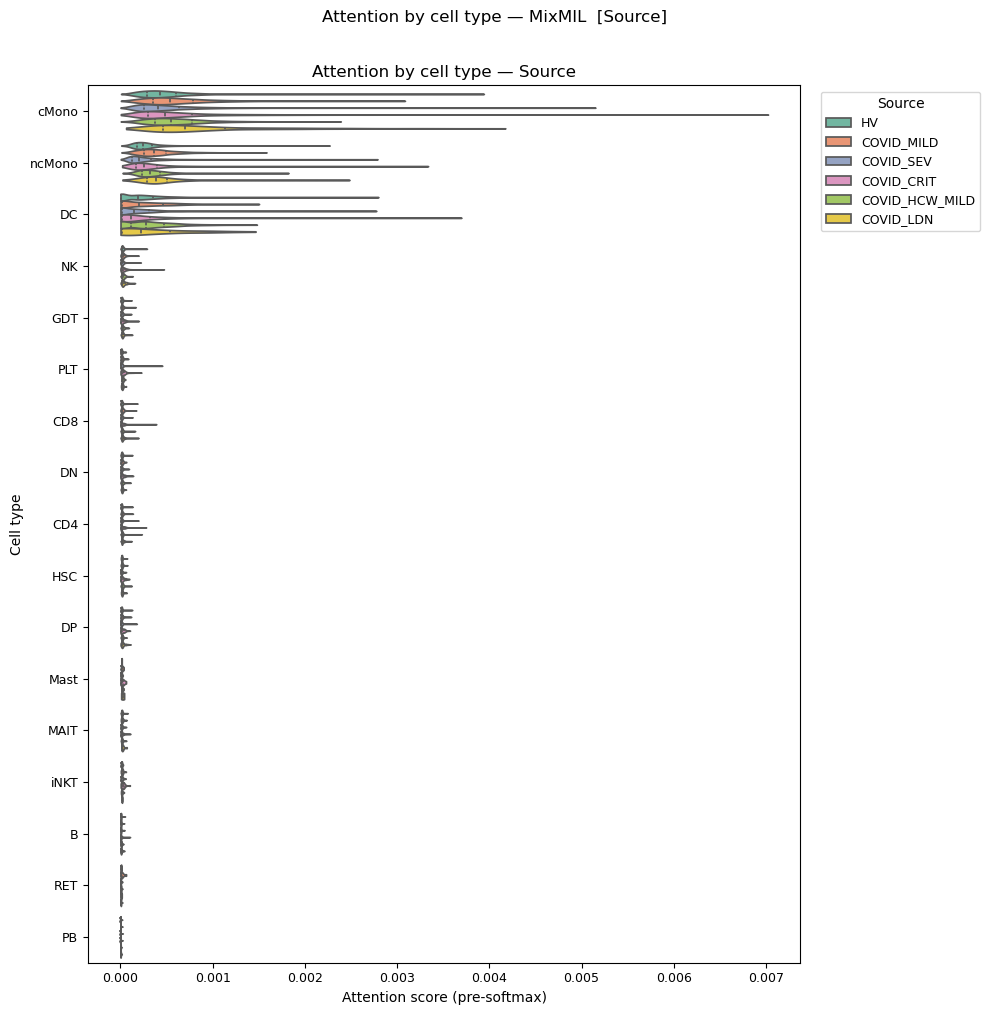

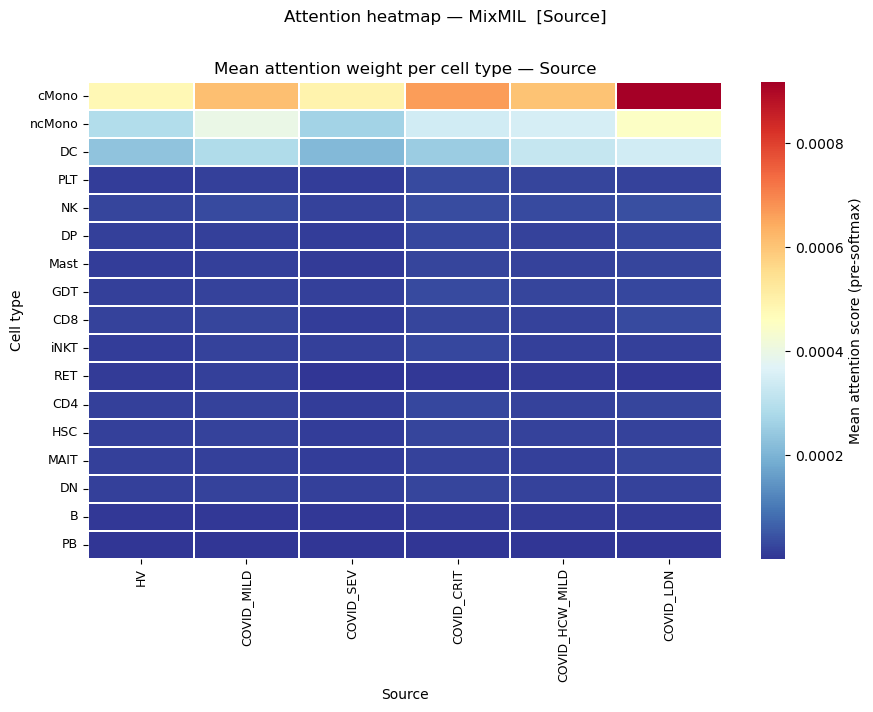

  → adata.obs['MixMIL_Source_attention'] written


No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


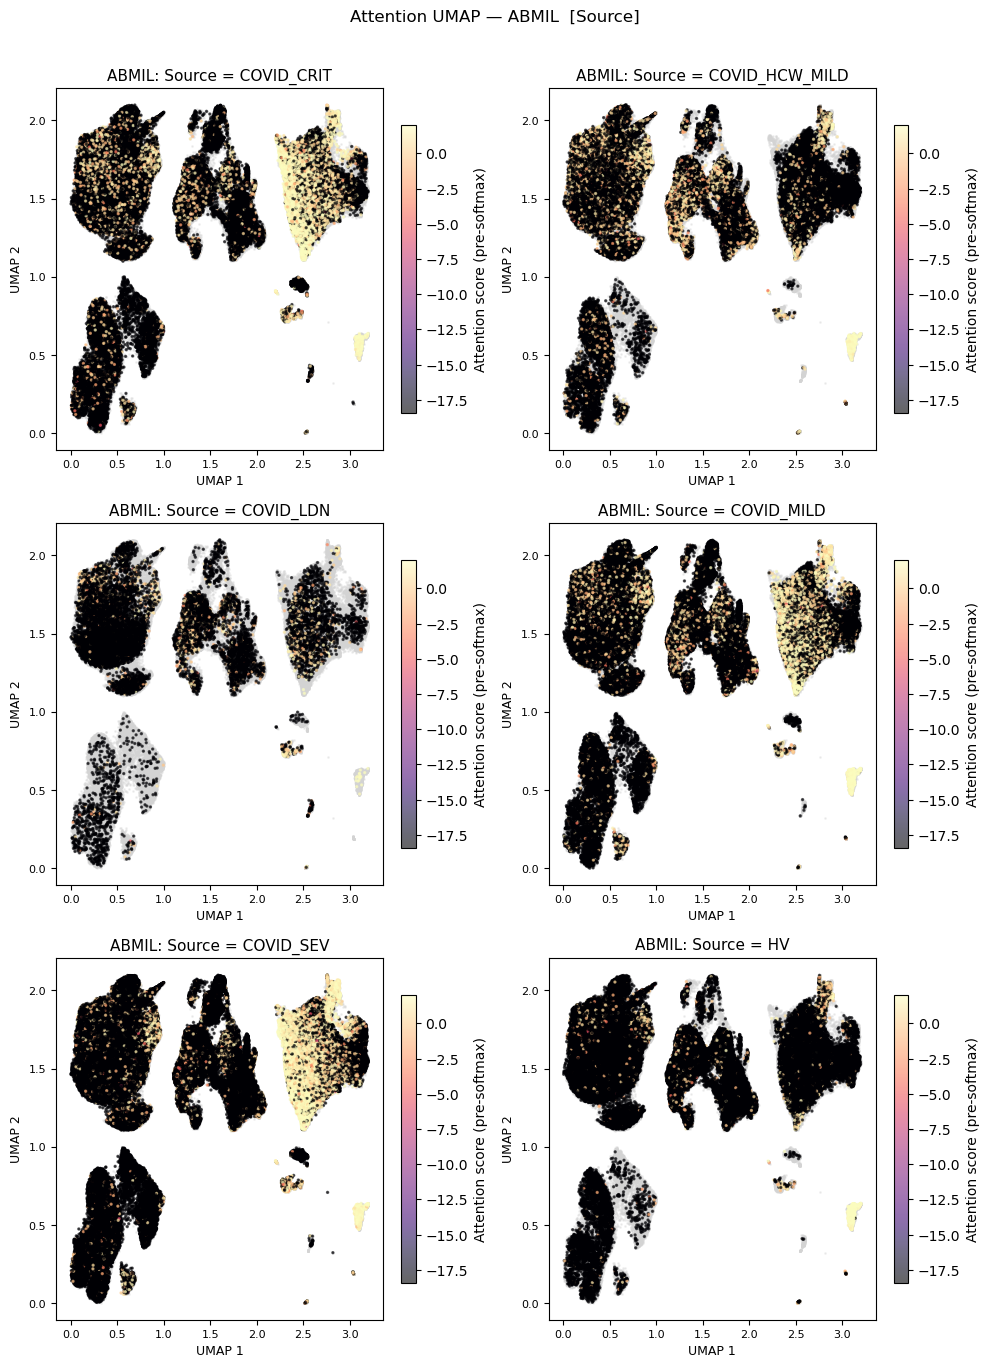

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


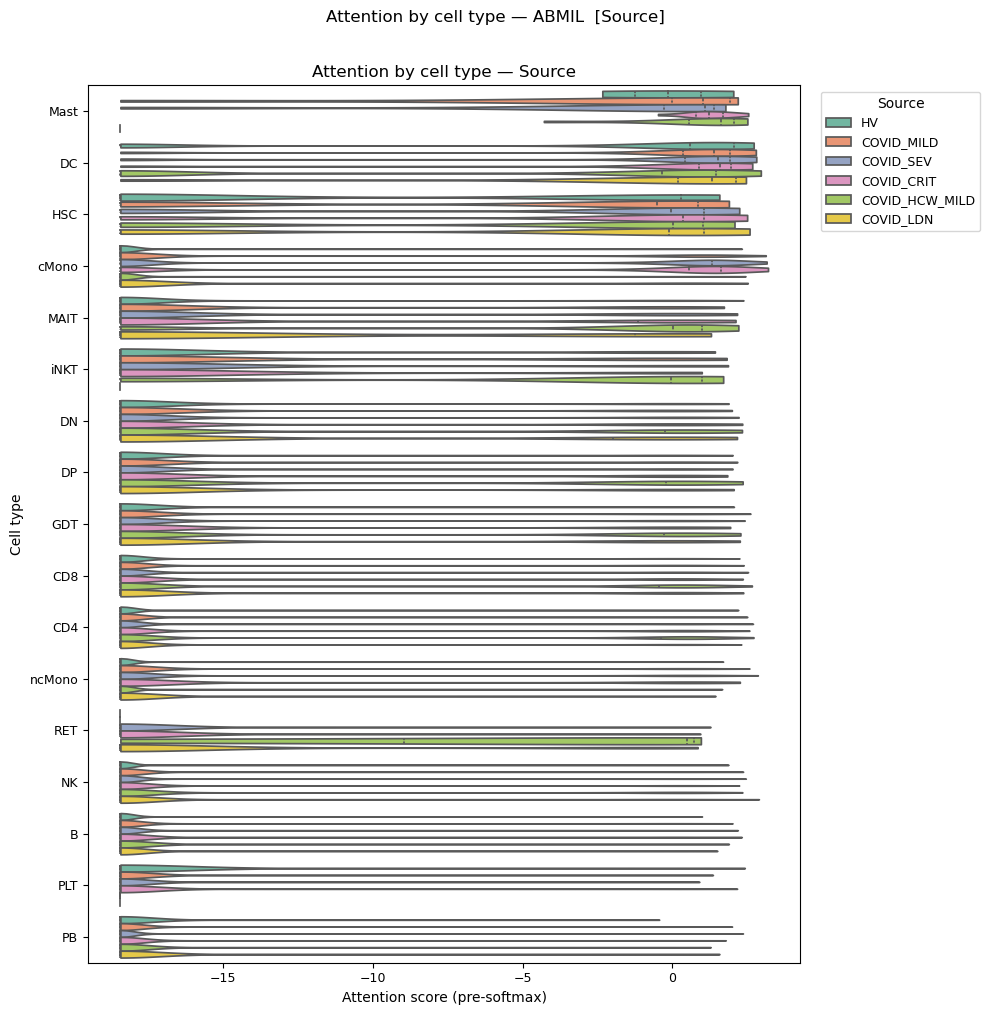

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


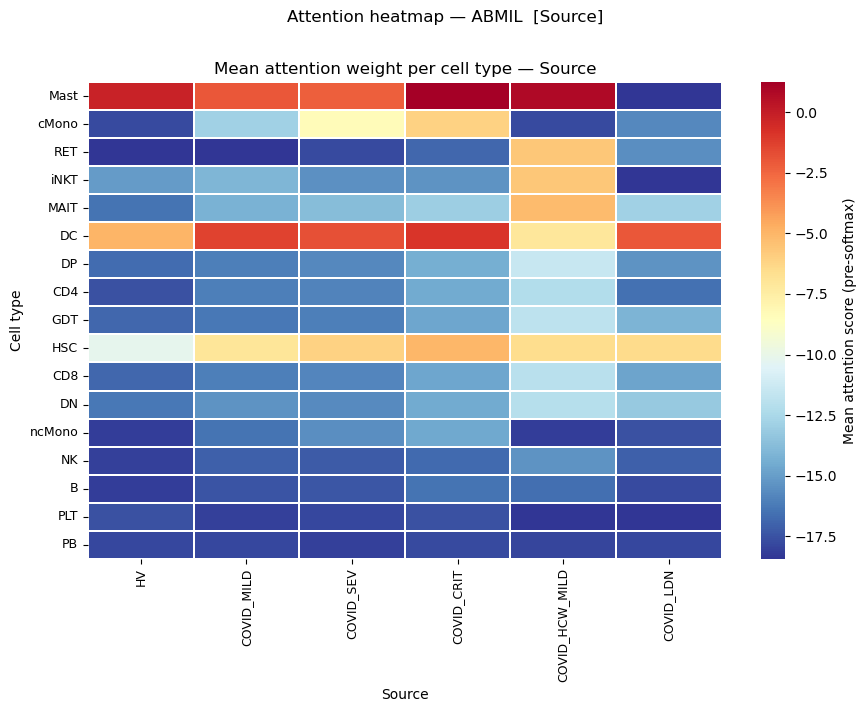

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


  → adata.obs['ABMIL_Source_attention'] written

  Label: Outcome  |  Task: classification


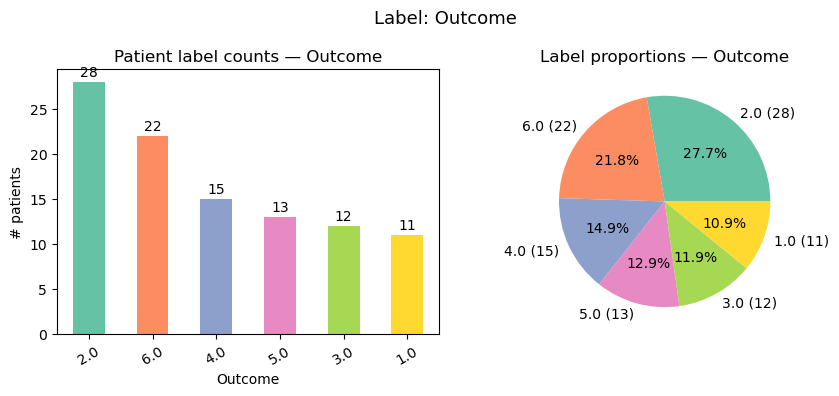

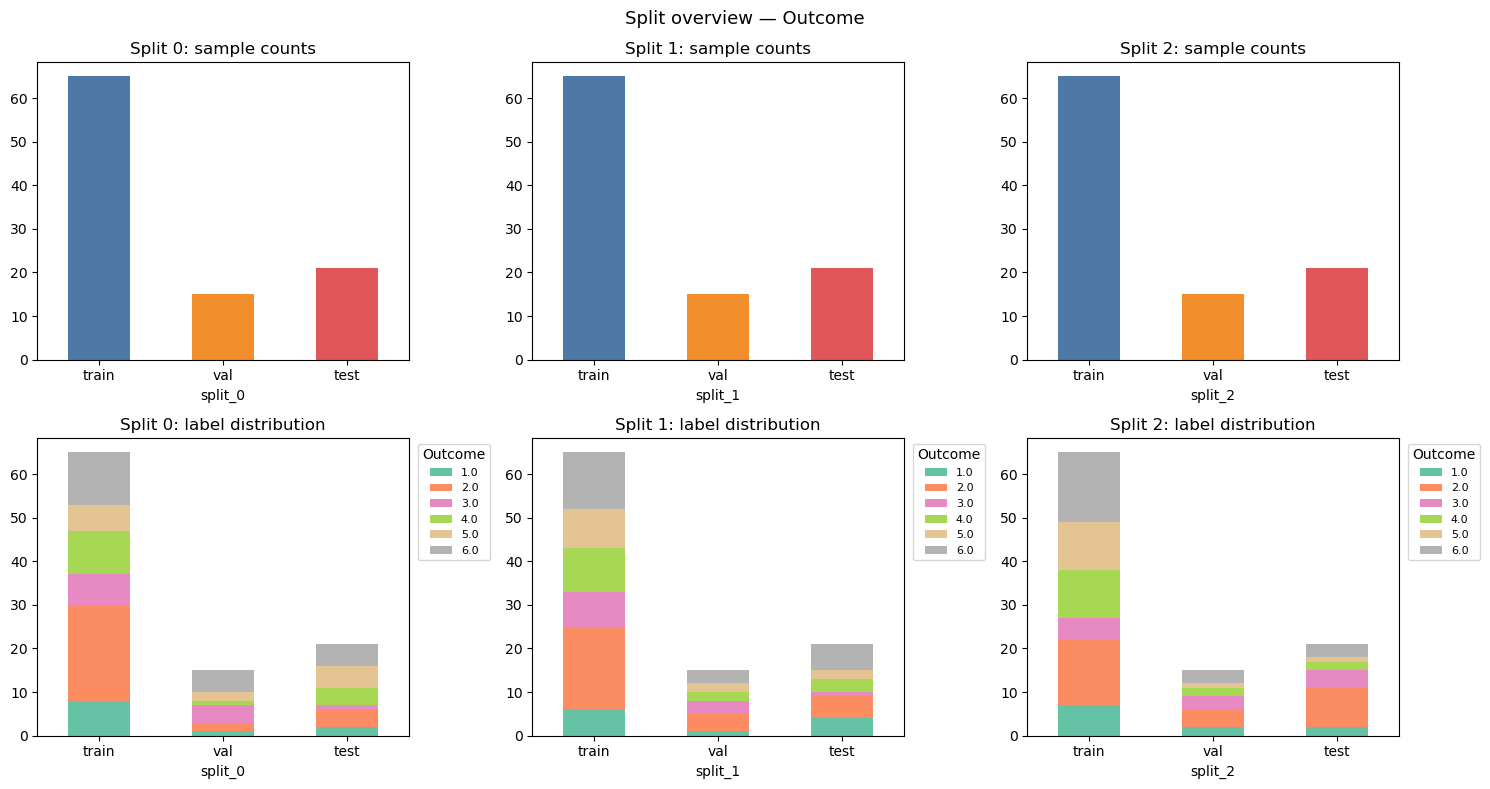

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                               mean     std
model  eval_split label   metric                           
ABMIL  test       Outcome auroc              0.7538  0.0944
                          balanced_accuracy  0.3448  0.0704
                          f1_weighted        0.4272  0.1054
       val        Outcome auroc              0.7965  0.0840
                          balanced_accuracy  0.4167  0.0833
                          f1_weighted        0.4661  0.0913
MixMIL test       Outcome auroc              0.7227  0.0181
                          balanced_accuracy  0.3216  0.0466
                          f1_weighted        0.3360  0.0715
       val        Outcome auroc              0.7907  0.0848
                          balanced_accuracy  0.3565  0.0289
                          f1_weighted        0.4206  0.0739


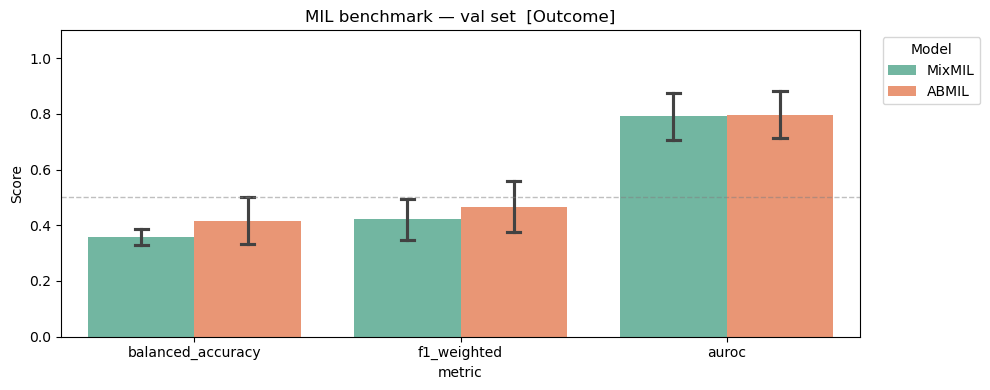

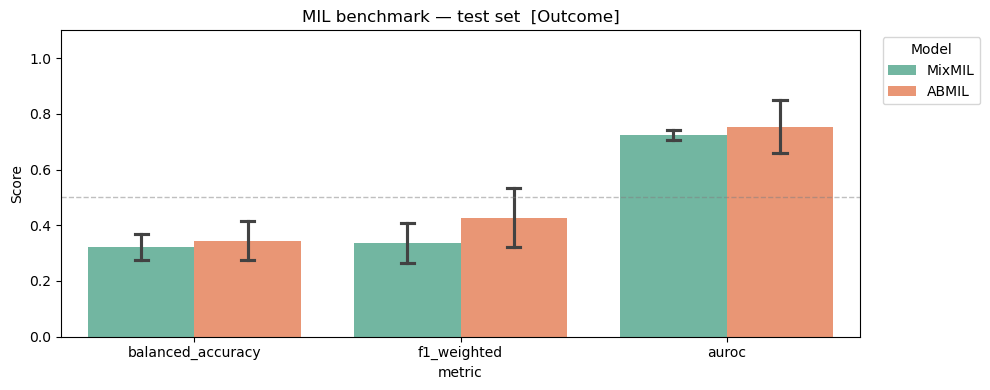

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

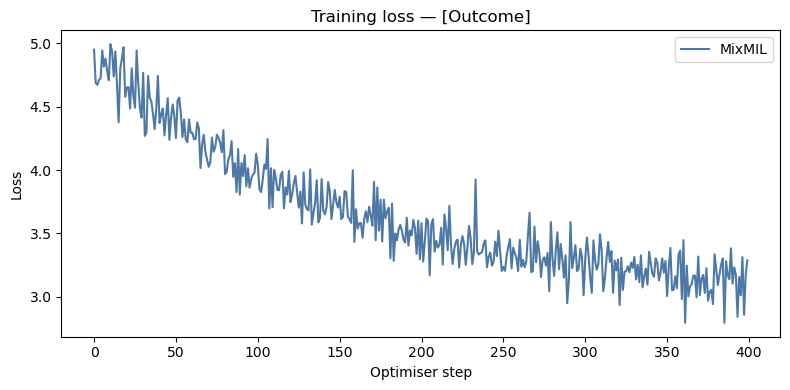

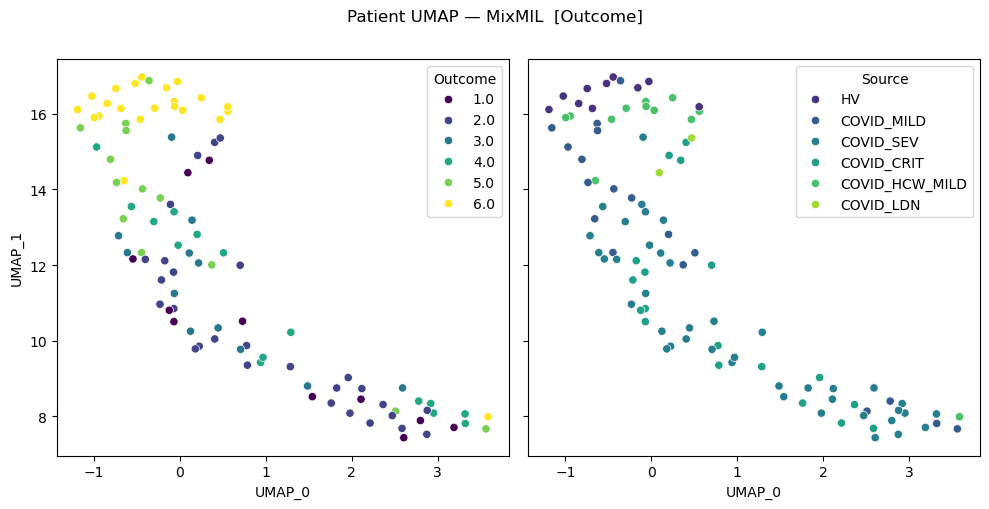

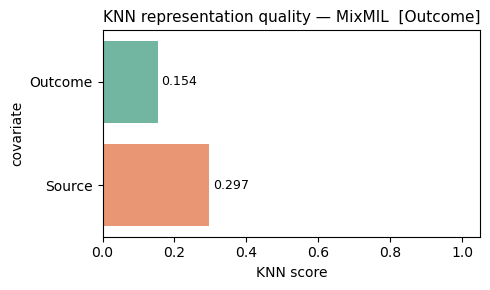

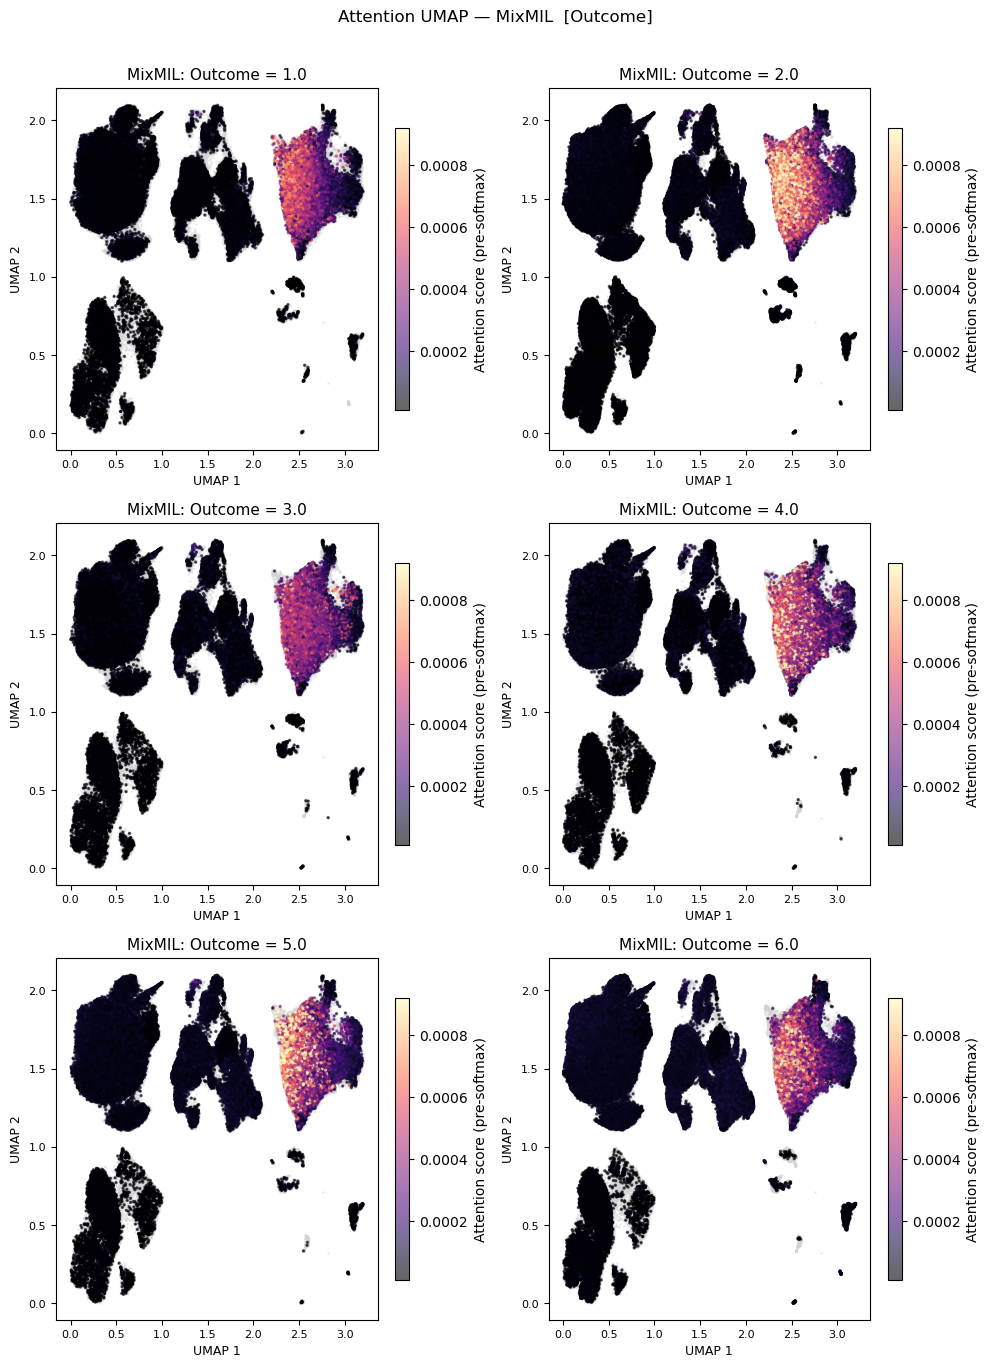

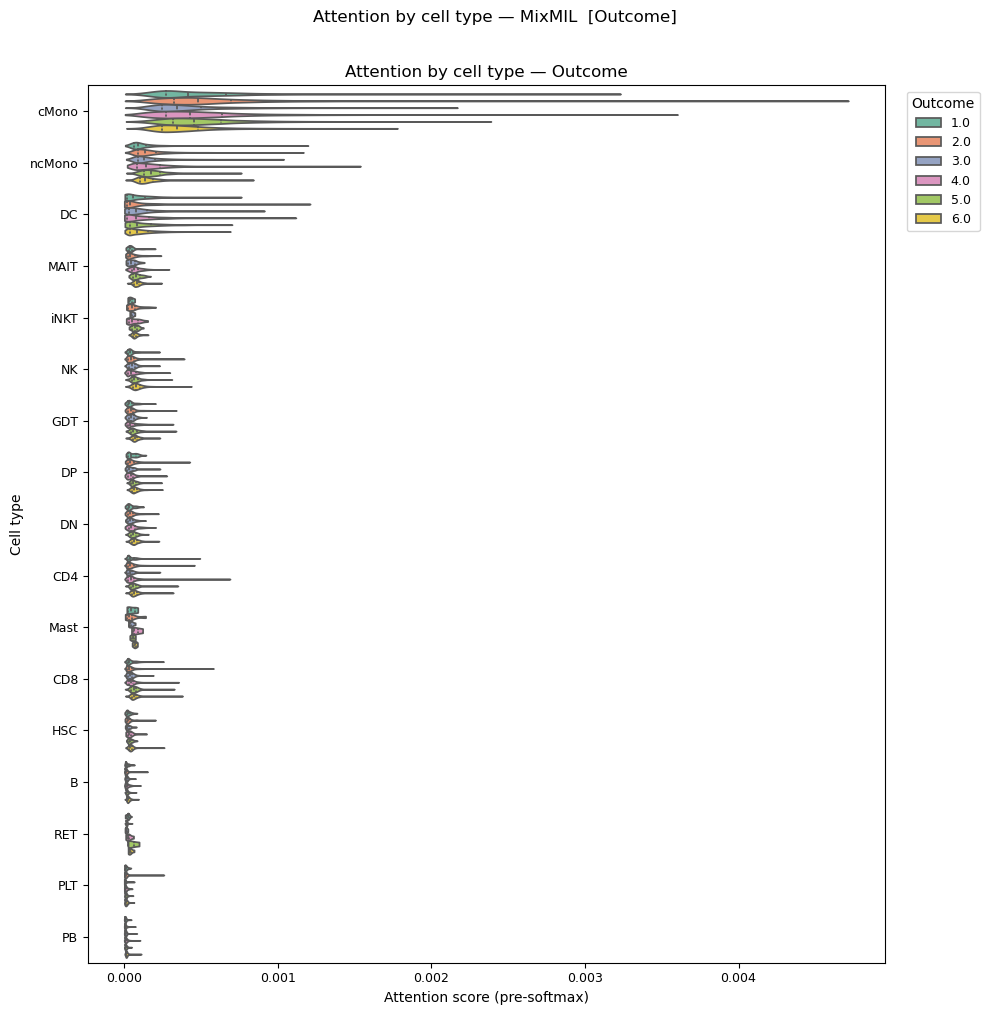

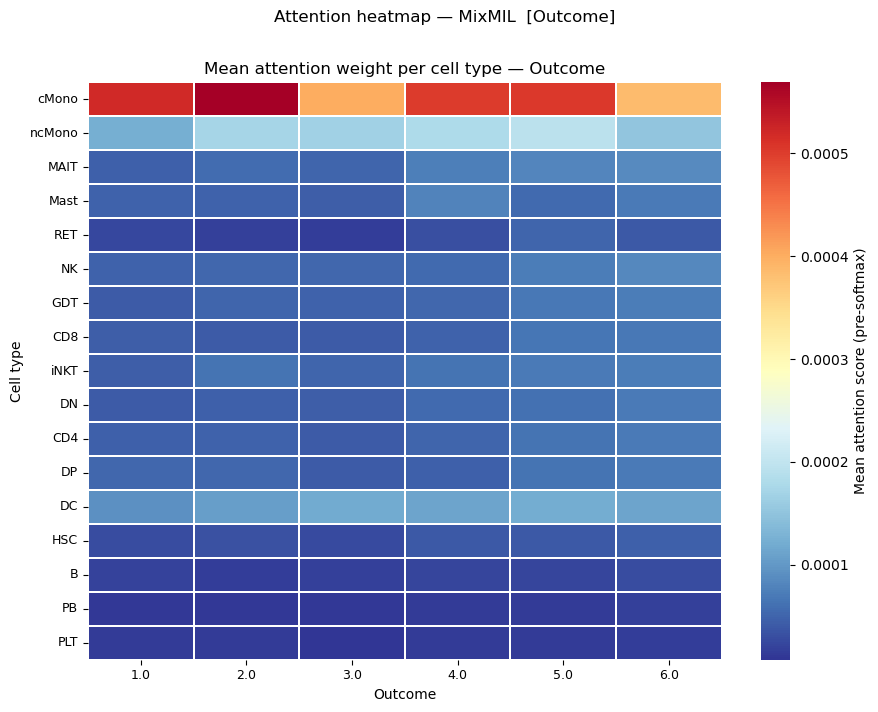

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


  → adata.obs['MixMIL_Outcome_attention'] written


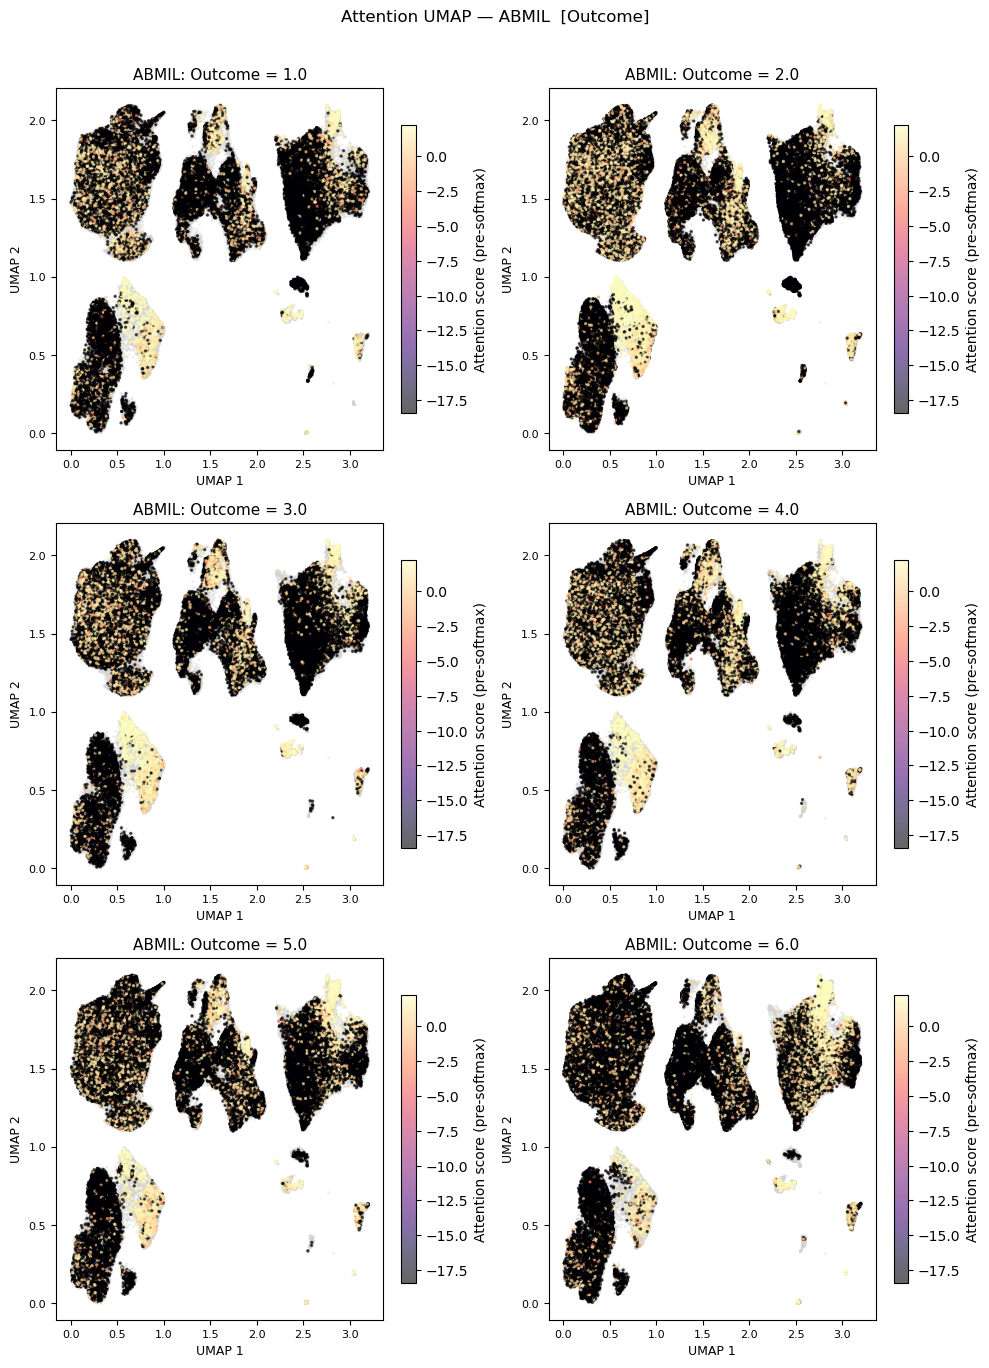

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


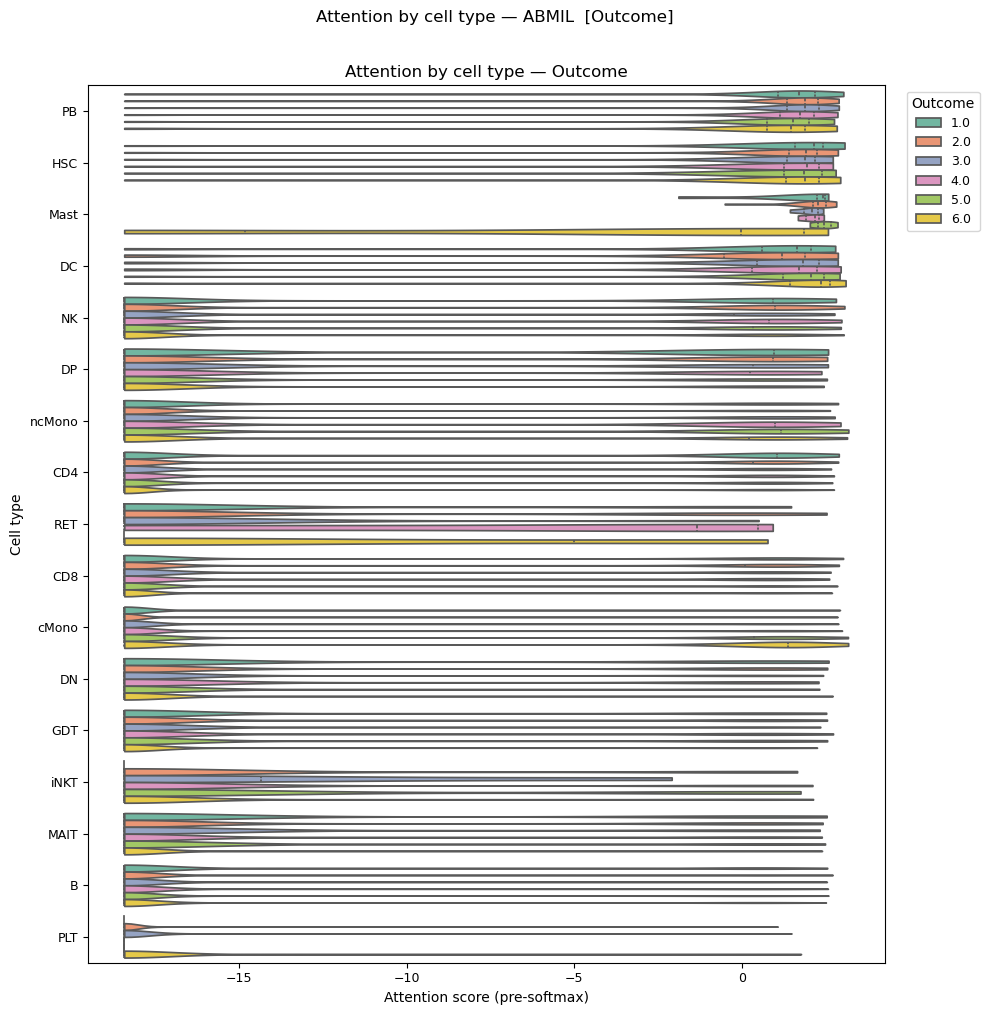

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


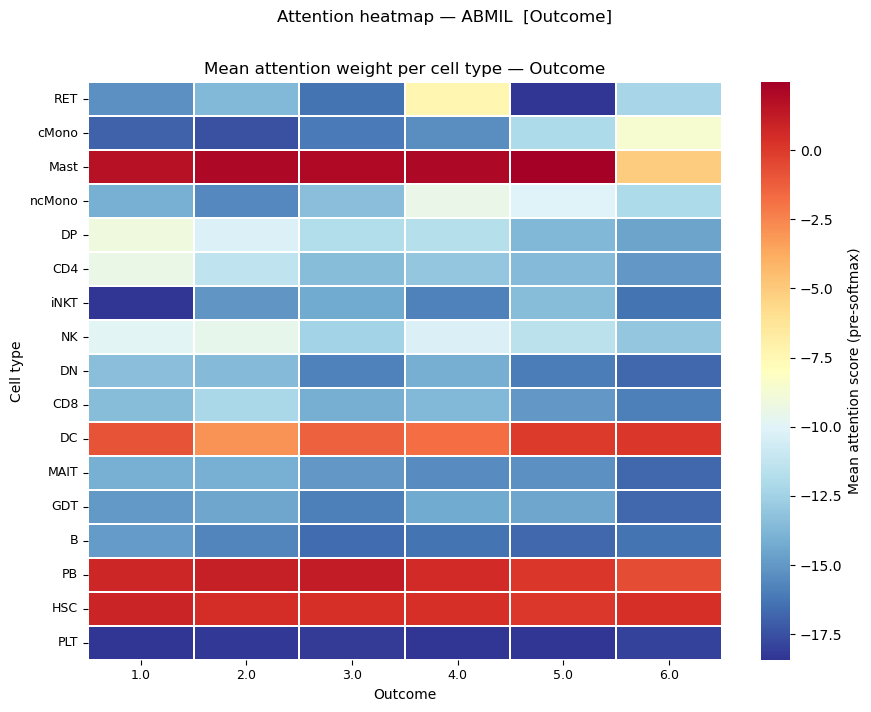

No nn.Softmax module found in ABMIL — returning log(normalized + 1e-8) as raw score proxy.


  → adata.obs['ABMIL_Outcome_attention'] written

All labels complete.


In [15]:
from sklearn.metrics import roc_curve, auc as sk_auc

all_results = {}
fitted_full = {}  # {label: {model_name: model}} — full-data retrains

cls_metrics = ["auroc", "balanced_accuracy", "f1_weighted", "aupr"]
reg_metrics = ["pearson", "r2", "mae"]

for label_key, task in LABELS.items():
    print(f"\n{"="*60}")
    print(f"  Label: {label_key}  |  Task: {task}")
    print(f"{"="*60}")

    # ── Label distribution ──────────────────────────────────────
    sample_labels = adata.obs.groupby(sample_key)[label_key].first().dropna()
    vc = sample_labels.value_counts()
    colors = sns.color_palette("Set2", len(vc))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    vc.plot.bar(ax=axes[0], color=colors)
    axes[0].set_title(f"Patient label counts — {label_key}")
    axes[0].set_ylabel("# patients")
    axes[0].tick_params(axis="x", rotation=30)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.3,
                     str(int(bar.get_height())), ha="center", va="bottom")
    axes[1].pie(vc.values, labels=[f"{k} ({v})" for k, v in vc.items()],
                autopct="%1.1f%%", colors=colors)
    axes[1].set_title(f"Label proportions — {label_key}")
    plt.suptitle(f"Label: {label_key}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Split overview ───────────────────────────────────────────
    sample_obs = adata.obs[[sample_key, label_key] + split_cols].groupby(sample_key).first()
    fig, axes = plt.subplots(2, len(split_cols), figsize=(5 * len(split_cols), 8), squeeze=False)
    for i, col in enumerate(split_cols):
        counts = sample_obs[col].value_counts().reindex(["train", "val", "test"]).fillna(0)
        counts.plot.bar(ax=axes[0][i], color=["#4e79a7", "#f28e2b", "#e15759"])
        axes[0][i].set_title(f"Split {i}: sample counts")
        axes[0][i].tick_params(axis="x", rotation=0)
        dist = (
            sample_obs.groupby([col, label_key]).size()
            .unstack(label_key, fill_value=0)
            .reindex(["train", "val", "test"]).fillna(0)
        )
        dist.plot.bar(stacked=True, ax=axes[1][i], colormap="Set2")
        axes[1][i].set_title(f"Split {i}: label distribution")
        axes[1][i].tick_params(axis="x", rotation=0)
        axes[1][i].legend(title=label_key, bbox_to_anchor=(1.01, 1),
                          loc="upper left", fontsize=8)
    fig.suptitle(f"Split overview — {label_key}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Benchmark ───────────────────────────────────────────────
    bench = MILBenchmark(
        models=make_models(label_key, task),
        sample_key=sample_key,
        label_keys=[label_key],
        tasks=[task],
        n_splits=3,
        seed=42,
    )
    results = bench.run(adata)
    all_results[label_key] = results

    print("\n--- Summary ---")
    print(bench.summary().to_string()) if not results.empty else print("  No results — all models failed.")

    # ── Eval metrics: train / val / test ─────────────────────────
    use_metrics = cls_metrics if task == "classification" else reg_metrics
    for split_name in ["train", "val", "test"]:
        subset = results[
            (results["eval_split"] == split_name) &
            (results["metric"].isin(use_metrics))
        ]
        if subset.empty:
            continue
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.barplot(data=subset, x="metric", y="value", hue="model",
                    ax=ax, errorbar="sd", capsize=0.1, palette="Set2")
        ax.set_ylim(0, 1.1)
        ax.axhline(0.5, color="grey", linestyle="--", lw=1, alpha=0.5)
        ax.set_title(f"MIL benchmark — {split_name} set  [{label_key}]", fontsize=12)
        ax.set_ylabel("Score")
        ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ── Full-dataset retrain (MixMIL + ABMIL) ────────────────────
    mixmil = MixMIL(sample_key=sample_key, label_keys=[label_key],
                    tasks=[task], layer="X_pca", n_epochs=200)
    mixmil.prepare_anndata(adata)

    abmil = ABMIL(sample_key=sample_key, label_keys=[label_key],
                  tasks=[task], layer="X_pca", att_dim=128, n_epochs=200)
    abmil.prepare_anndata(adata)


    fitted_full[label_key] = {"MixMIL": mixmil, "ABMIL": abmil}

    # ── Training loss ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    for model, name, color in [(mixmil, "MixMIL", "#4e79a7"), (abmil, "ABMIL", "#f28e2b")]:
        hist = getattr(model, "training_history", None)
        if hist:
            losses = [step["loss"] for step in hist if "loss" in step]
            ax.plot(losses, label=name, lw=1.5, color=color)
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Loss")
    ax.set_title(f"Training loss — [{label_key}]")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Patient representation UMAP (MixMIL) ─────────────────────
    extra_cols = [c for c in ["Source", "Outcome"] if c != label_key and c in metadata.columns]
    mixmil.plot_embedding(
        method="UMAP",
        metadata_cols=[label_key] + extra_cols,
        categorical_palette="tab10",
    )
    plt.suptitle(f"Patient UMAP — MixMIL  [{label_key}]", y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Representation quality scores ─────────────────────────────
    distances = mixmil.calculate_distance_matrix()
    eval_cols = {label_key: task}
    for ec in extra_cols:
        eval_cols[ec] = "classification"
    rows = []
    for col, ctask in eval_cols.items():
        target = metadata.loc[mixmil.samples, col].dropna()
        if target.nunique() < 2:
            continue
        try:
            res = patpy.tl.evaluate_representation(
                distances, target=target, task=ctask,
                n_neighbors=min(5, len(target) - 1))
            rows.append({"covariate": col, "score": res["score"], "metric": res["metric"]})
        except Exception as e:
            print(f"  rep_quality {col}: {e}")
    if rows:
        rep_df = pd.DataFrame(rows)
        fig, ax = plt.subplots(figsize=(5, max(3, 0.6 * len(rep_df))))
        sns.barplot(data=rep_df, y="covariate", x="score", orient="h", ax=ax, palette="Set2")
        ax.set_xlim(0, 1.05)
        ax.set_title(f"KNN representation quality — MixMIL  [{label_key}]", fontsize=11)
        ax.set_xlabel("KNN score")
        for bar in ax.patches:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.3f}", va="center", fontsize=9)
        plt.tight_layout()
        plt.show()

    # ── ROC curve (classification only, first test fold) ──────────
    if task == "classification":
        test_adata = adata[adata.obs[split_cols[0]] == "test"]
        y_true_series = test_adata.obs.groupby(sample_key)[label_key].first().dropna()
        classes = sorted(y_true_series.unique())
        if len(classes) == 2:
            enc = {c: i for i, c in enumerate(classes)}
            y_true = y_true_series.map(enc).values
            fig, ax = plt.subplots(figsize=(5, 5))
            for model, name in [(mixmil, "MixMIL"), (abmil, "ABMIL")]:
                try:
                    preds = model.predict_on_adata(test_adata, label_key)
                    prob_cols = [c for c in preds.columns if c.startswith("prob_")]
                    if len(prob_cols) < 2:
                        continue
                    proba = preds[prob_cols[1]].reindex(y_true_series.index).values
                    fpr, tpr, _ = roc_curve(y_true, proba)
                    ax.plot(fpr, tpr, lw=2, label=f"{name}  AUC={sk_auc(fpr, tpr):.3f}")
                except Exception as e:
                    print(f"  ROC {name}: {e}")
            ax.plot([0, 1], [0, 1], "k--", lw=1)
            ax.set_xlabel("FPR")
            ax.set_ylabel("TPR")
            ax.set_title(f"ROC — {label_key}  (test fold 0)")
            ax.legend(loc="lower right")
            plt.tight_layout()
            plt.show()

    # ── Attention plots ───────────────────────────────────────────
    for model, name in [(mixmil, "MixMIL"), (abmil, "ABMIL")]:
        try:
            fig = patpy.pl.mil.plot_attention_umap(
                adata, model, label_key,
                cell_type_key=cell_type_key, umap_key="X_umap",
                sample_key=sample_key, normalized=False,
                title_prefix=f"{name}: ",
            )
            plt.suptitle(f"Attention UMAP — {name}  [{label_key}]", y=1.01)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  attention_umap {name}: {e}")

        try:
            fig = patpy.pl.mil.plot_attention_by_cell_type(
                adata, model, label_key,
                cell_type_key=cell_type_key, sample_key=sample_key, normalized=False,
            )
            plt.suptitle(f"Attention by cell type — {name}  [{label_key}]", y=1.01)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  attention_celltype {name}: {e}")

        try:
            fig = patpy.pl.mil.plot_attention_celltype_heatmap(
                adata, model, label_key,
                cell_type_key=cell_type_key, sample_key=sample_key, normalized=False,
            )
            plt.suptitle(f"Attention heatmap — {name}  [{label_key}]", y=1.01)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  attention_heatmap {name}: {e}")

        # Save attention to adata.obs
        try:
            att_df = _get_importance(model, label_key)
            src_col = f"{label_key}_importance"
            dst_col = f"{name}_{label_key}_attention"
            if src_col in att_df.columns:
                adata.obs[dst_col] = att_df[src_col].values
                print(f"  → adata.obs['{dst_col}'] written")
        except Exception as e:
            print(f"  save_attention {name}: {e}")

print("\nAll labels complete.")


## Representation benchmark — linear probe evaluation

MIL models learn supervised representations, but simpler **unsupervised** aggregations (pseudobulk means, cell-type proportions) can also encode clinically relevant information.  Here we compare all of them on equal footing by:

1. **Computing representations** for each patient:
   - *Pseudobulk* — mean of per-cell PCA embeddings per patient
   - *CellGroupComposition* — fraction of cells per cell-type cluster
   - *GroupedPseudobulk* — concatenation of per-cell-type pseudobulk means
   - *MixMIL (reps)* — the bag embedding from a trained MixMIL model (fit on train split)
   - *ABMIL (reps)* — the attention-weighted bag embedding from a trained ABMIL model

2. **Fitting a linear probe** (LogisticRegression for classification, Ridge for regression) on the **training-split** representations only

3. **Evaluating** on validation and test splits using the same metrics as the MIL benchmark

> **Key insight**: if a simple linear probe on pseudobulk means matches MIL performance, the MIL model is not adding value beyond simple aggregation.  Where MIL beats pseudobulk, it has learned a non-trivial reweighting of cells.



  Rep-Benchmark  Label: binary_condition  |  Task: classification


GLMM Init:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                                                   mean     std
model             eval_split label            metric                           
ABMIL (reps)      test       binary_condition aupr               1.0000  0.0000
                                              auroc              1.0000  0.0000
                                              balanced_accuracy  0.9079  0.1374
                                              f1_weighted        0.9672  0.0290
                  val        binary_condition aupr               1.0000  0.0000
                                              auroc              1.0000  0.0000
                                              balanced_accuracy  0.9872  0.0222
                                              f1_weighted        0.9796  0.0354
CellComposition   test       binary_condition aupr               0.9906  0.0098
                                              auroc              0.9123  0.0846
                       

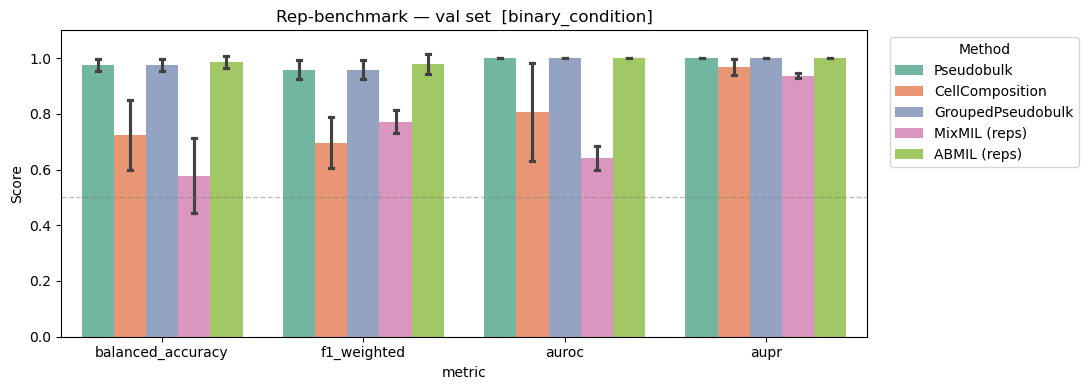

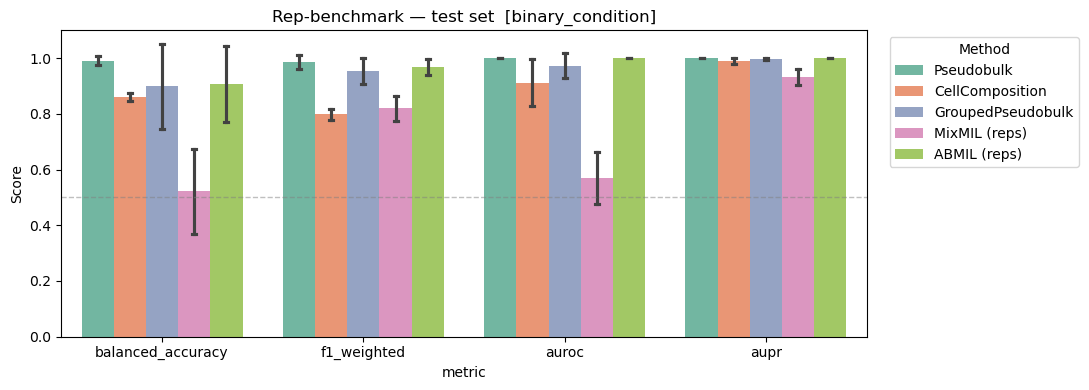


  Rep-Benchmark  Label: Source  |  Task: classification


GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                                         mean     std
model             eval_split label  metric                           
ABMIL (reps)      test       Source balanced_accuracy  0.5773  0.1498
                                    f1_weighted        0.4705  0.1163
                  val        Source balanced_accuracy  0.7296  0.1649
                                    f1_weighted        0.7087  0.1729
CellComposition   test       Source balanced_accuracy  0.2900  0.1082
                                    f1_weighted        0.2324  0.0821
                  val        Source balanced_accuracy  0.2404  0.0875
                                    f1_weighted        0.3099  0.1724
GroupedPseudobulk test       Source balanced_accuracy  0.5072  0.1554
                                    f1_weighted        0.4598  0.0931
                  val        Source balanced_accuracy  0.7108  0.0967
                                    f1_weighted        0.6897  0.1398
Mix

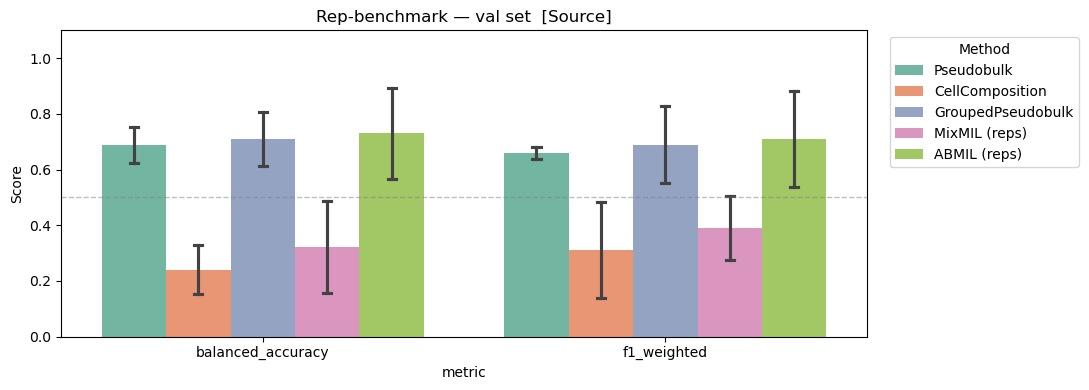

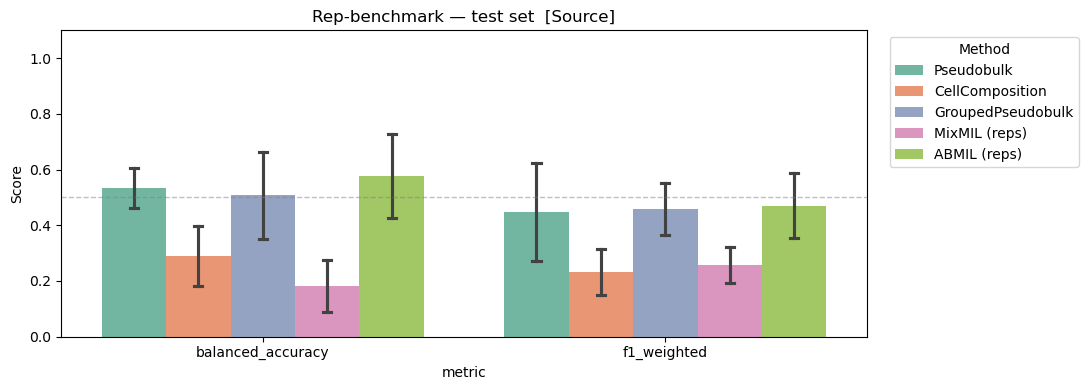


  Rep-Benchmark  Label: Outcome  |  Task: classification


GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

GLMM Init:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]


--- Summary ---
                                                          mean     std
model             eval_split label   metric                           
ABMIL (reps)      test       Outcome auroc              0.7551  0.1077
                                     balanced_accuracy  0.3691  0.0342
                                     f1_weighted        0.4158  0.0574
                  val        Outcome auroc              0.7764  0.1085
                                     balanced_accuracy  0.4630  0.0642
                                     f1_weighted        0.5595  0.0999
CellComposition   test       Outcome auroc              0.6234  0.0411
                                     balanced_accuracy  0.3191  0.0998
                                     f1_weighted        0.2284  0.0293
                  val        Outcome auroc              0.6195  0.0459
                                     balanced_accuracy  0.3065  0.1389
                                     f1_weighted        0.29

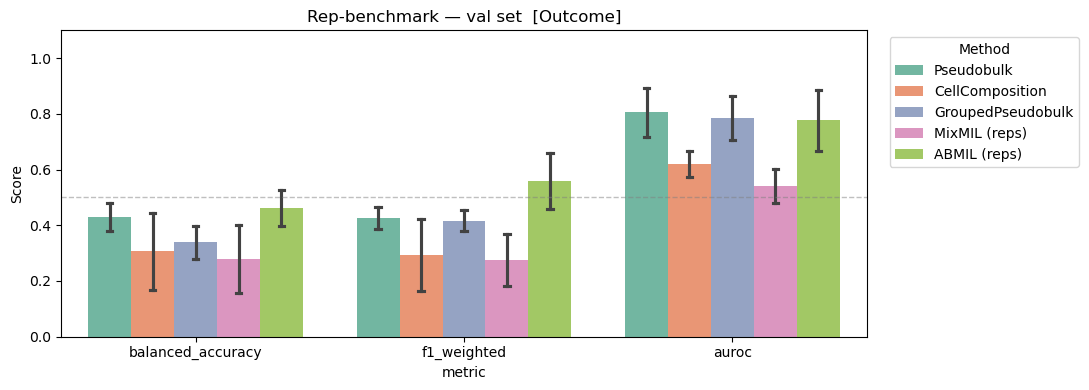

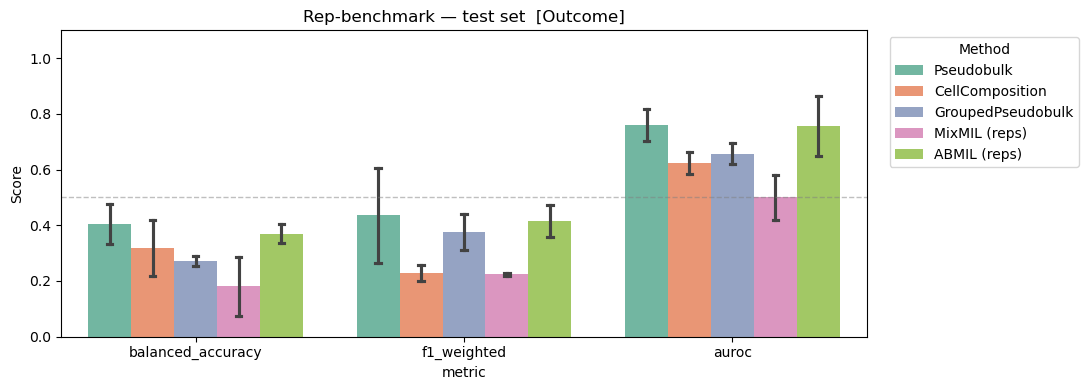


All labels complete.


In [16]:
from patpy.tl import RepresentationBenchmark
from patpy.tl import Pseudobulk, CellGroupComposition, GroupedPseudobulk

rep_cls_metrics = ["auroc", "balanced_accuracy", "f1_weighted", "aupr"]
rep_reg_metrics = ["pearson", "r2", "mae"]

all_rep_results = {}

for label_key, task in LABELS.items():
    print(f"\n{'='*60}")
    print(f"  Rep-Benchmark  Label: {label_key}  |  Task: {task}")
    print(f"{'='*60}")

    rep_models = {
        "Pseudobulk": Pseudobulk(
            sample_key=sample_key, cell_group_key=cell_type_key, layer="X_pca"),
        "CellComposition": CellGroupComposition(
            sample_key=sample_key, cell_group_key=cell_type_key),
        "GroupedPseudobulk": GroupedPseudobulk(
            sample_key=sample_key, cell_group_key=cell_type_key, layer="X_pca"),
        "MixMIL (reps)": MixMIL(
            sample_key=sample_key, label_keys=[label_key],
            tasks=[task], layer="X_pca", n_epochs=200),
        "ABMIL (reps)": ABMIL(
            sample_key=sample_key, label_keys=[label_key],
            tasks=[task], layer="X_pca", att_dim=128, n_epochs=200),
    }

    rep_bench = RepresentationBenchmark(
        models=rep_models,
        sample_key=sample_key,
        label_keys=[label_key],
        tasks=[task],
        n_splits=3,
        seed=42,
    )
    rep_results = rep_bench.run(adata)
    all_rep_results[label_key] = rep_results

    if rep_results.empty:
        print("  No results — all rep models failed.")
        continue

    print("\n--- Summary ---")
    print(rep_bench.summary().to_string())

    # ── Metrics barplot ──────────────────────────────────────────
    use_metrics = rep_cls_metrics if task == "classification" else rep_reg_metrics
    for split_name in ["val", "test"]:
        subset = rep_results[
            (rep_results["eval_split"] == split_name) &
            (rep_results["metric"].isin(use_metrics))
        ]
        if subset.empty:
            continue
        fig, ax = plt.subplots(figsize=(11, 4))
        sns.barplot(data=subset, x="metric", y="value", hue="model",
                    ax=ax, errorbar="sd", capsize=0.1, palette="Set2")
        ax.set_ylim(0, 1.1)
        ax.axhline(0.5, color="grey", linestyle="--", lw=1, alpha=0.5)
        ax.set_title(f"Rep-benchmark — {split_name} set  [{label_key}]", fontsize=12)
        ax.set_ylabel("Score")
        ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

print("\nAll labels complete.")


## Combined results across all labels

A single bar chart comparing test AUROC for both MIL models across all three prediction targets, followed by the full numeric table.


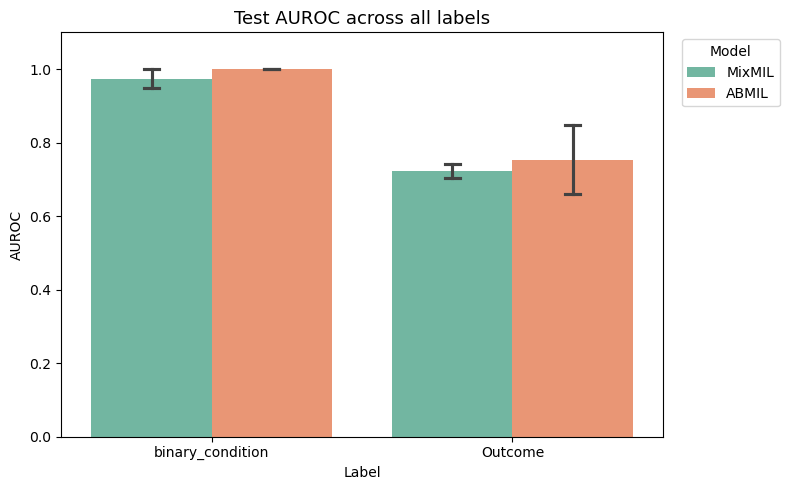

mean     std
label_trained    model  eval_split metric                           
Outcome          ABMIL  test       auroc              0.7538  0.0944
                                   balanced_accuracy  0.3448  0.0704
                                   f1_weighted        0.4272  0.1054
                        val        auroc              0.7965  0.0840
                                   balanced_accuracy  0.4167  0.0833
                                   f1_weighted        0.4661  0.0913
                 MixMIL test       auroc              0.7227  0.0181
                                   balanced_accuracy  0.3216  0.0466
                                   f1_weighted        0.3360  0.0715
                        val        auroc              0.7907  0.0848
                                   balanced_accuracy  0.3565  0.0289
                                   f1_weighted        0.4206  0.0739
Source           ABMIL  test       balanced_accuracy  0.5703  0.1772
                                   f1_weighted        0.4820  0.1138
                        val        balanced_accuracy  0.7574  0.1472
                                   f1_weighted        0.7280  0.1822
                 MixMIL test       balanced_accuracy  0.4419  0.0812
                                   f1_weighted        0.3744  0.0901
                        val        balanced_accuracy  0.5403  0.1439
                                   f1_weighted        0.4495  0.2348
binary_condition ABMIL  test       aupr               1.0000  0.0000
                                   auroc              1.0000  0.0000
                                   balanced_accuracy  0.9167  0.1443
                                   f1_weighted        0.9817  0.0317
                        val        aupr               1.0000  0.0000
                                   auroc              1.0000  0.0000
                                   balanced_accuracy  1.0000  0.0000
                                   f1_weighted        1.0000  0.0000
                 MixMIL test       aupr               0.9975  0.0025
                                   auroc              0.9737  0.0263
                                   balanced_accuracy  0.7456  0.0662
                                   f1_weighted        0.6183  0.1124
                        val        aupr               1.0000  0.0000
                                   auroc              1.0000  0.0000
                                   balanced_accuracy  0.7949  0.0588
                                   f1_weighted        0.6971  0.0920

In [17]:
all_df = pd.concat(
    [df.assign(label_trained=lk) for lk, df in all_results.items()],
    ignore_index=True
)

test_all = all_df[
    (all_df["eval_split"] == "test") &
    (all_df["metric"] == "auroc")
]

if not test_all.empty:
    fig, ax = plt.subplots(figsize=(max(8, 2 * len(LABELS)), 5))
    sns.barplot(data=test_all, x="label_trained", y="value", hue="model",
                ax=ax, errorbar="sd", capsize=0.1, palette="Set2")
    ax.set_ylim(0, 1.1)
    ax.set_title("Test AUROC across all labels", fontsize=13)
    ax.set_ylabel("AUROC")
    ax.set_xlabel("Label")
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

all_df.groupby(["label_trained", "model", "eval_split", "metric"])["value"].agg(["mean", "std"]).round(4)


## Summary

| Step | patpy function |
|------|---------------|
| QC — filter small patients | `patpy.pp.filter_small_samples` |
| QC — cell counts & composition | `patpy.pp.calculate_n_cells_per_sample`, `calculate_compositional_metrics` |
| Stratified splits | `patpy.pp.make_sample_splits` |
| Cross-validated benchmark (per label) | `patpy.tl.MILBenchmark` |
| Patient representation UMAP | `model.plot_embedding` |
| Representation quality | `patpy.tl.evaluate_representation` |
| Attention on cell UMAP | `patpy.pl.mil.plot_attention_umap` |
| Attention by cell type | `patpy.pl.mil.plot_attention_by_cell_type` |
| Attention heatmap | `patpy.pl.mil.plot_attention_celltype_heatmap` |
